# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings

import warnings

In [2]:
# Import the libraries you will be using for analysis
#!pip install numpy==1.26.4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file

df = pd.read_parquet('2023-1.parquet')
df.info()

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/data/')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()
print(file_list)

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        df_month = pd.read_parquet(file_path)


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in df_month['tpep_pickup_datetime'].dt.date.unique():
          for hour in range(24):
            hour_data = df_month[(df_month['tpep_pickup_datetime'].dt.hour == hour) \
                                 & (df_month['tpep_pickup_datetime'].dt.date == date)]
            sample = hour_data.sample(frac = 0.05, random_state = 42)
            sampled_data = pd.concat([sampled_data, sample])

            # Iterate through each hour of the selected date

                # Sample 5% of the hourly data randomly

                # add data of this hour to the dataframe

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df,sampled_data])# we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [8]:
# Store the df in csv/parquet
df.to_parquet('combined.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [9]:
# Load the new data file
df = pd.read_parquet('combined.parquet')


In [10]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
428,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1113,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
819,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3192,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
2995263,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1889084 entries, 428 to 3196303
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            fl

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [12]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)
df.drop('store_and_fwd_flag', axis = 1,inplace=True)


In [13]:
df.shape

(1889084, 19)

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [14]:
# Combine the two airport fee columns

df['airport_fee'].fillna(0, inplace=True)
df['Airport_fee'].fillna(0, inplace=True)
df['airport_fee'] = df['airport_fee'] + df['Airport_fee']
df.drop(['Airport_fee'], axis=1, inplace=True)


/tmp/ipykernel_9655/1809913057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['airport_fee'].fillna(0, inplace=True)
/tmp/ipykernel_9655/1809913057.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [15]:
# check where values of fare amount are negative
df[df['fare_amount'] <= 0]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
3119,1,2023-01-01 19:16:54,2023-01-01 19:17:15,1.0,0.00,2.0,261,261,3,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00
3966,2,2023-01-02 05:12:19,2023-01-02 05:41:45,1.0,17.07,3.0,142,1,2,0.0,0.00,0.0,0.0,0.0,-1.0,-1.00,0.0,0.00
5039,1,2023-01-02 13:44:07,2023-01-02 13:48:36,0.0,0.00,1.0,145,145,1,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00
7701,2,2023-01-03 08:27:38,2023-01-03 08:59:16,1.0,8.34,1.0,161,244,2,0.0,0.00,0.5,0.0,0.0,1.0,4.00,2.5,0.00
9093,2,2023-01-03 14:24:45,2023-01-03 14:25:14,1.0,0.00,2.0,132,132,2,0.0,0.00,-0.5,0.0,0.0,-1.0,-5.25,-2.5,-1.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866611,1,2023-12-27 20:51:43,2023-12-27 21:00:02,3.0,0.00,5.0,132,215,4,0.0,1.75,0.0,0.0,0.0,1.0,2.75,0.0,1.75
1867582,1,2023-12-24 02:28:52,2023-12-24 02:36:27,0.0,1.40,5.0,186,48,3,0.0,0.00,0.0,0.0,0.0,1.0,1.00,0.0,0.00
1879409,1,2023-12-29 16:02:56,2023-12-29 16:03:31,0.0,0.00,5.0,132,132,3,0.0,1.75,0.0,0.0,0.0,1.0,2.75,0.0,1.75
1879545,2,2023-12-29 17:32:20,2023-12-29 17:33:49,1.0,0.02,1.0,161,161,2,0.0,0.00,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00


Did you notice something different in the `RatecodeID` column for above records?

In [16]:
# Analyse RatecodeID for the negative fare amounts
df[df['fare_amount'] <= 0][['RatecodeID']].value_counts()


,count
RatecodeID,
1.0,378
5.0,158
2.0,56
99.0,24
4.0,13
3.0,4


In [17]:
df['RatecodeID'].value_counts()

,count
RatecodeID,
1.0,1722583
2.0,71432
99.0,10436
5.0,10248
3.0,6102
4.0,3716
6.0,3


In [18]:
df['RatecodeID'].mode()

,RatecodeID
0,1.0


In [19]:
df.loc[df['RatecodeID'] == 99.0, 'RatecodeID'] = df['RatecodeID'].mode()[0]

In [20]:
df['RatecodeID'].value_counts()

,count
RatecodeID,
1.0,1733019
2.0,71432
5.0,10248
3.0,6102
4.0,3716
6.0,3


In [21]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [22]:
# Find which columns have negative values
cols_to_check = ['passenger_count', 'trip_distance', 'RatecodeID',
                 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
                 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
                 'total_amount', 'congestion_surcharge', 'airport_fee']

min_values_series = df[cols_to_check].min()

# Filter this series to find columns where the minimum value is less than 0
negative_min_columns = min_values_series[min_values_series < 0]

print("Columns with negative values and their minimums:")
print(negative_min_columns)

Columns with negative values and their minimums:
extra                   -2.50
mta_tax                 -0.50
improvement_surcharge   -1.00
total_amount            -5.75
congestion_surcharge    -2.50
airport_fee             -1.75
dtype: float64


In [23]:
# Fix these negative values by replacing them with the median of each column

# Calculate medians for each column with negative values
median_extra = df['extra'].median()
median_mta_tax = df['mta_tax'].median()
median_improvement_surcharge = df['improvement_surcharge'].median()
median_total_amount = df['total_amount'].median()
median_congestion_surcharge = df['congestion_surcharge'].median()
median_airport_fee = df['airport_fee'].median()

# Apply corrections using .loc to avoid SettingWithCopyWarning
df.loc[df['extra'] < 0, 'extra'] = median_extra
df.loc[df['mta_tax'] < 0, 'mta_tax'] = median_mta_tax
df.loc[df['improvement_surcharge'] < 0, 'improvement_surcharge'] = median_improvement_surcharge
df.loc[df['total_amount'] < 0, 'total_amount'] = median_total_amount
df.loc[df['congestion_surcharge'] < 0, 'congestion_surcharge'] = median_congestion_surcharge
df.loc[df['airport_fee'] < 0, 'airport_fee'] = median_airport_fee


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [24]:
# Find the proportion of missing values in each column

df.isnull().mean()

,0
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,0.034177
trip_distance,0.000000
RatecodeID,0.034177
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000
fare_amount,0.000000


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [25]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
df[df['passenger_count'].isnull()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,0.0
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,NaN,10.77,NaN,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,0.0
42,2,2023-01-01 00:37:21,2023-01-01 00:54:18,NaN,4.52,NaN,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,NaN,0.0
43,2,2023-01-01 00:44:03,2023-01-01 01:13:49,NaN,9.19,NaN,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,NaN,0.0
46,2,2023-01-01 00:50:55,2023-01-01 01:19:06,NaN,2.74,NaN,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1889059,2,2023-12-31 23:09:34,2023-12-31 23:36:00,NaN,4.10,NaN,140,249,0,23.47,0.0,0.5,0.00,0.00,1.0,27.47,NaN,0.0
1889063,2,2023-12-31 23:05:26,2023-12-31 23:18:01,NaN,3.24,NaN,229,239,0,17.33,0.0,0.5,0.00,0.00,1.0,21.33,NaN,0.0
1889074,2,2023-12-31 23:38:22,2024-01-01 00:02:48,NaN,8.38,NaN,244,137,0,34.93,0.0,0.5,0.00,0.00,1.0,38.93,NaN,0.0
1889076,2,2023-12-31 23:35:59,2023-12-31 23:39:21,NaN,0.76,NaN,141,140,0,6.83,0.0,0.5,0.00,0.00,1.0,10.83,NaN,0.0


In [26]:
df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)
df['passenger_count'].isnull().sum()

/tmp/ipykernel_9655/736688748.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)


np.int64(0)

Did you find zeroes in passenger_count? Handle these.

In [27]:
df['passenger_count'].value_counts()

,count
passenger_count,
1.0,1436486
2.0,276251
3.0,68768
4.0,38396
0.0,29580
5.0,23775
6.0,15807
8.0,11
9.0,5


In [28]:
df.loc[df['passenger_count'] == 0, 'passenger_count'] = df['passenger_count'].mode()[0]
df['passenger_count'].value_counts()

,count
passenger_count,
1.0,1466066
2.0,276251
3.0,68768
4.0,38396
5.0,23775
6.0,15807
8.0,11
9.0,5
7.0,5


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [29]:
# Fix missing values in 'RatecodeID'
df['RatecodeID'].isnull().sum()

np.int64(64564)

In [30]:
df['RatecodeID'].fillna(df['RatecodeID'].median(), inplace=True)

/tmp/ipykernel_9655/898901588.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RatecodeID'].fillna(df['RatecodeID'].median(), inplace=True)


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [31]:
# handle null values in congestion_surcharge

df['congestion_surcharge'].isnull().sum()


np.int64(64564)

In [32]:
df['congestion_surcharge'].fillna(df['congestion_surcharge'].median(), inplace=True)

/tmp/ipykernel_9655/3502353311.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['congestion_surcharge'].fillna(df['congestion_surcharge'].median(), inplace=True)


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [33]:
# Handle any remaining missing values

df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0


In [34]:
df.dropna(subset=['total_amount'], inplace=True)
print(df.shape)

(1889084, 18)


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [35]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe().T



,count,mean,min,25%,50%,75%,max,std
VendorID,1889084.0,1.733018,1.0,1.0,2.0,2.0,6.0,0.447652
tpep_pickup_datetime,1889084,2023-07-02 20:29:47.321815,2022-12-31 23:51:30,2023-04-02 17:04:27.500000,2023-06-27 16:38:39,2023-10-06 19:18:16.750000,2023-12-31 23:57:51,NaN
tpep_dropoff_datetime,1889084,2023-07-02 20:47:13.496013,2022-12-31 23:56:06,2023-04-02 17:23:31.250000,2023-06-27 16:56:18.500000,2023-10-06 19:35:34.250000,2024-01-01 20:50:55,NaN
passenger_count,1889084.0,1.372274,1.0,1.0,1.0,1.0,9.0,0.864461
trip_distance,1889084.0,3.860392,0.0,1.05,1.8,3.4,126360.46,129.658603
RatecodeID,1889084.0,1.071882,1.0,1.0,1.0,1.0,6.0,0.387437
PULocationID,1889084.0,165.280803,1.0,132.0,162.0,234.0,265.0,64.000933
DOLocationID,1889084.0,164.048275,1.0,114.0,162.0,234.0,265.0,69.802997
payment_type,1889084.0,1.163817,0.0,1.0,1.0,1.0,4.0,0.508057
fare_amount,1889084.0,19.922422,0.0,9.3,13.5,21.9,143163.45,105.735992


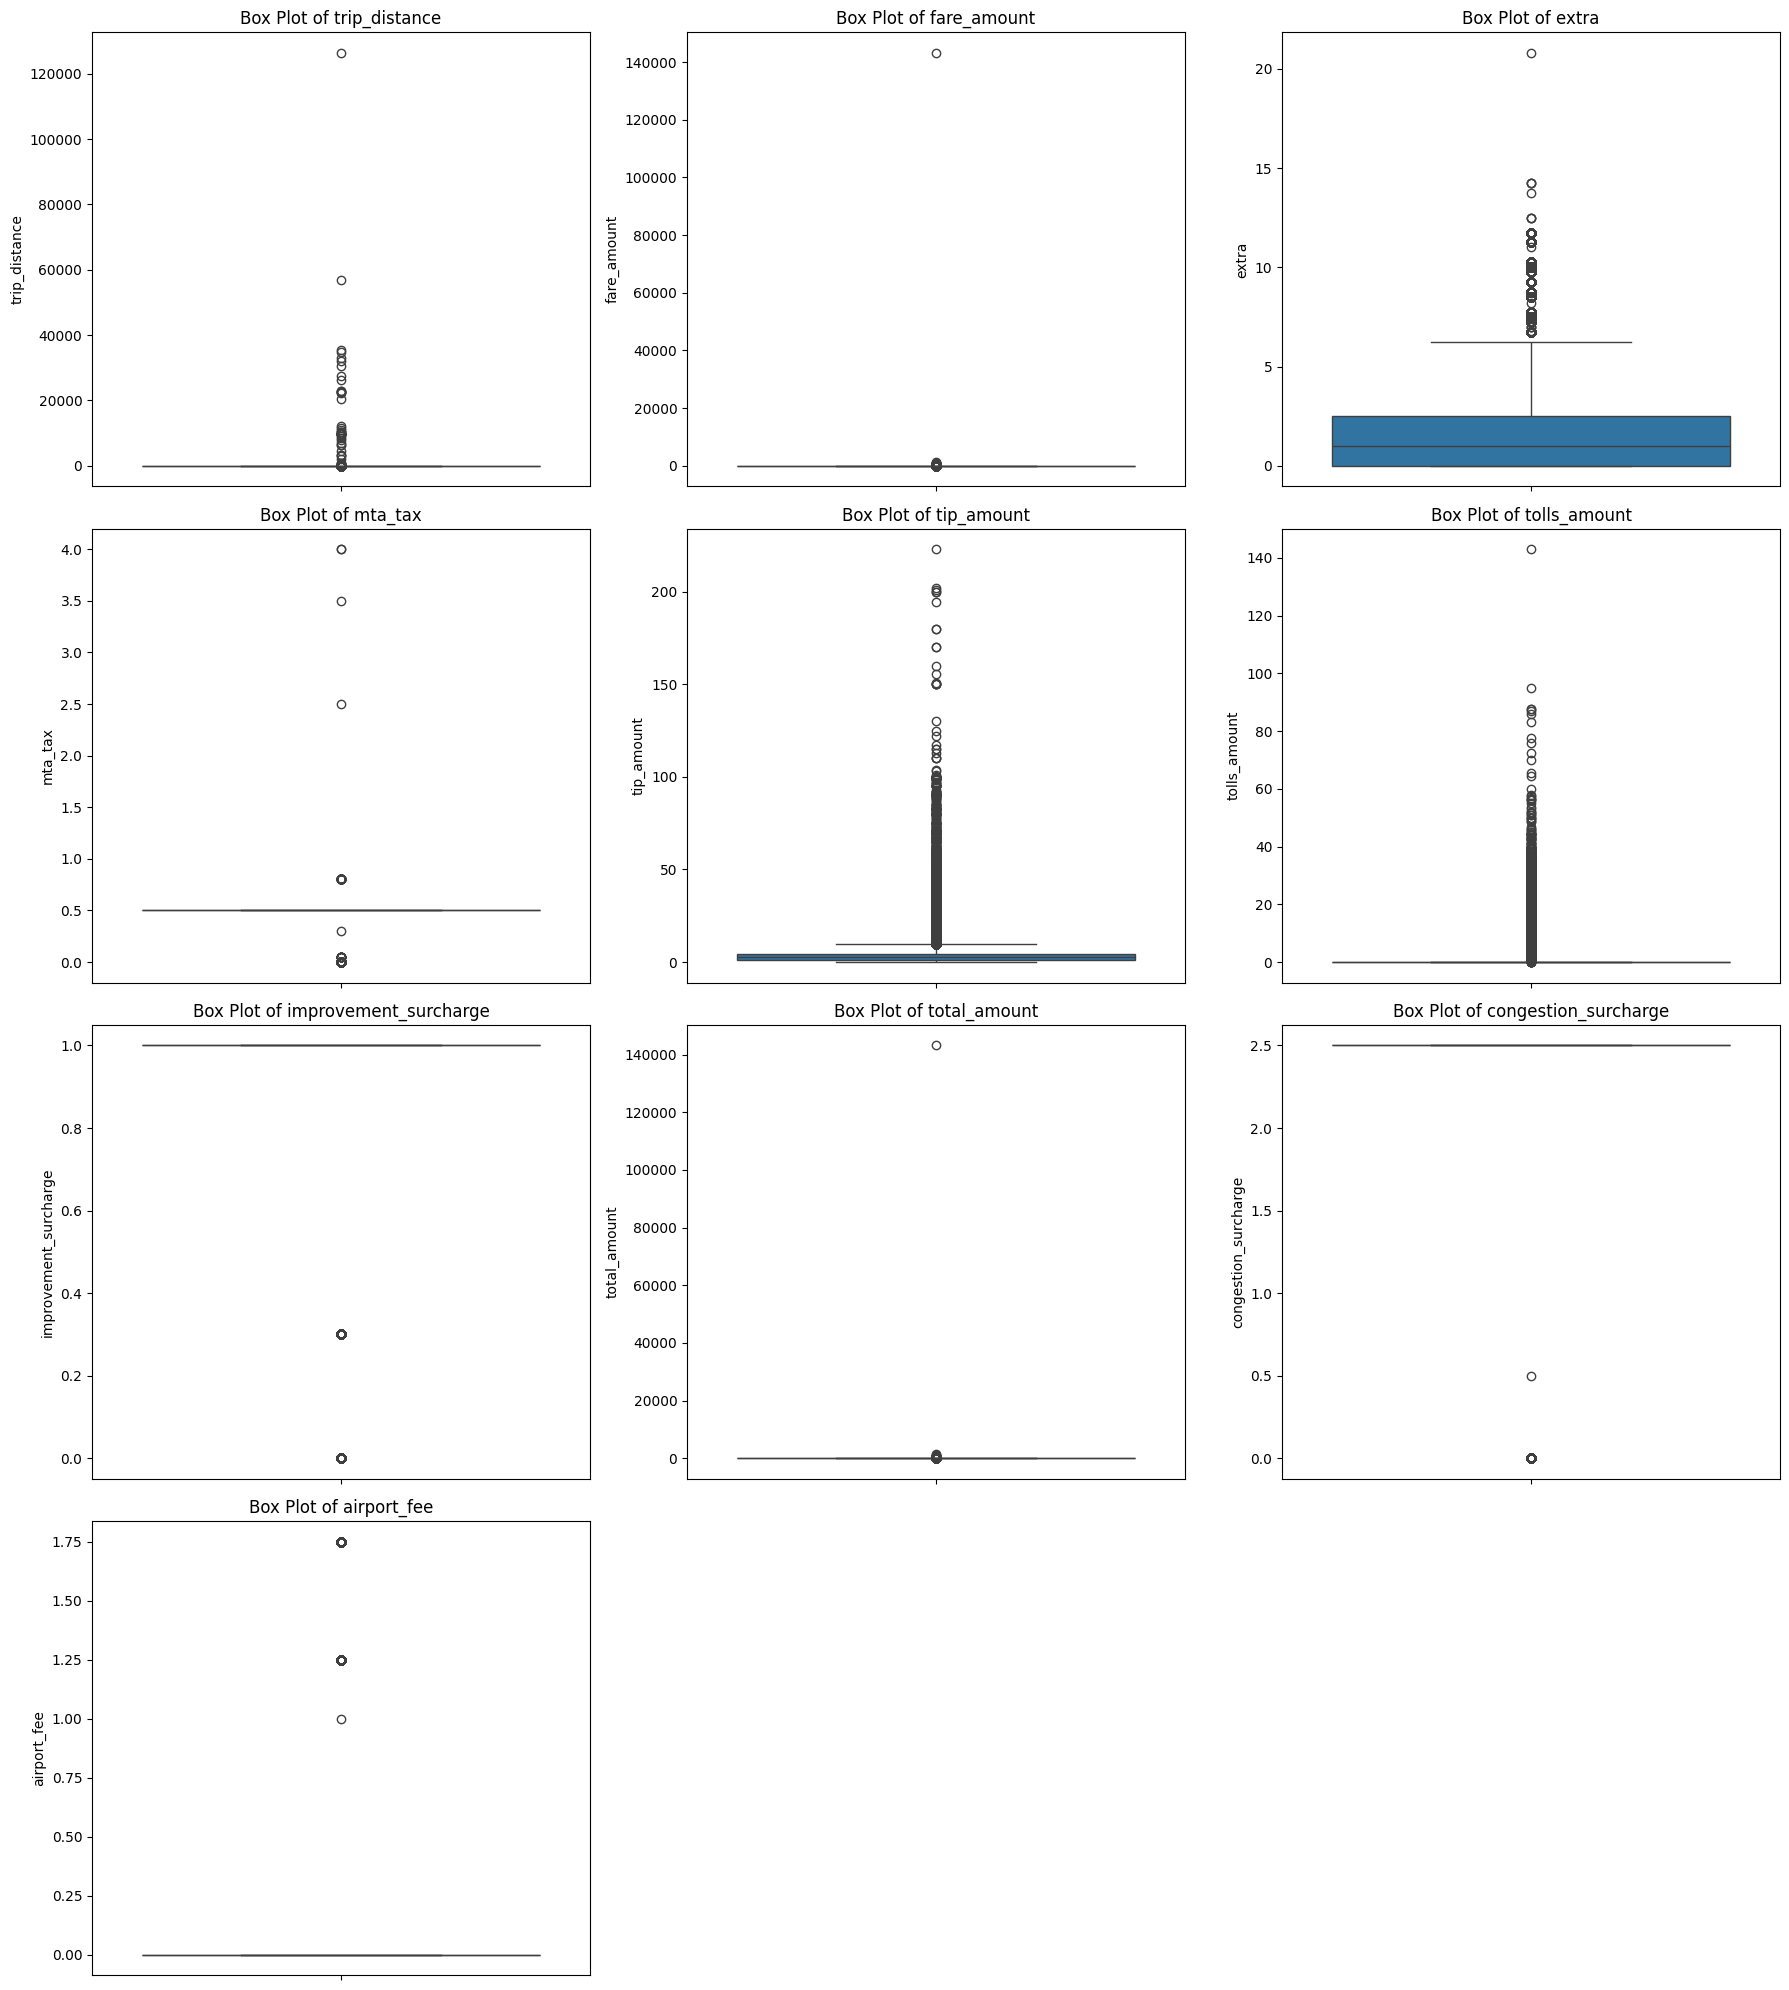

In [36]:
numeric_cols_for_boxplot = [
    'trip_distance',
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

# Calculate the number of rows and columns for the subplots
num_cols = 3
num_rows = (len(numeric_cols_for_boxplot) + num_cols - 1) // num_cols

# Create a single figure with multiple subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 5))
axes = axes.flatten()

# Loop through each selected numeric column and create a box plot in a subplot
for i, col in enumerate(numeric_cols_for_boxplot):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(len(numeric_cols_for_boxplot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [37]:
cols = [
    'trip_distance',
    'payment_type',
    'tip_amount'
]

# Loop through each selected numeric column and create a box plot in a subplot
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    plt.show()


/tmp/ipykernel_9655/799298506.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette='viridis')


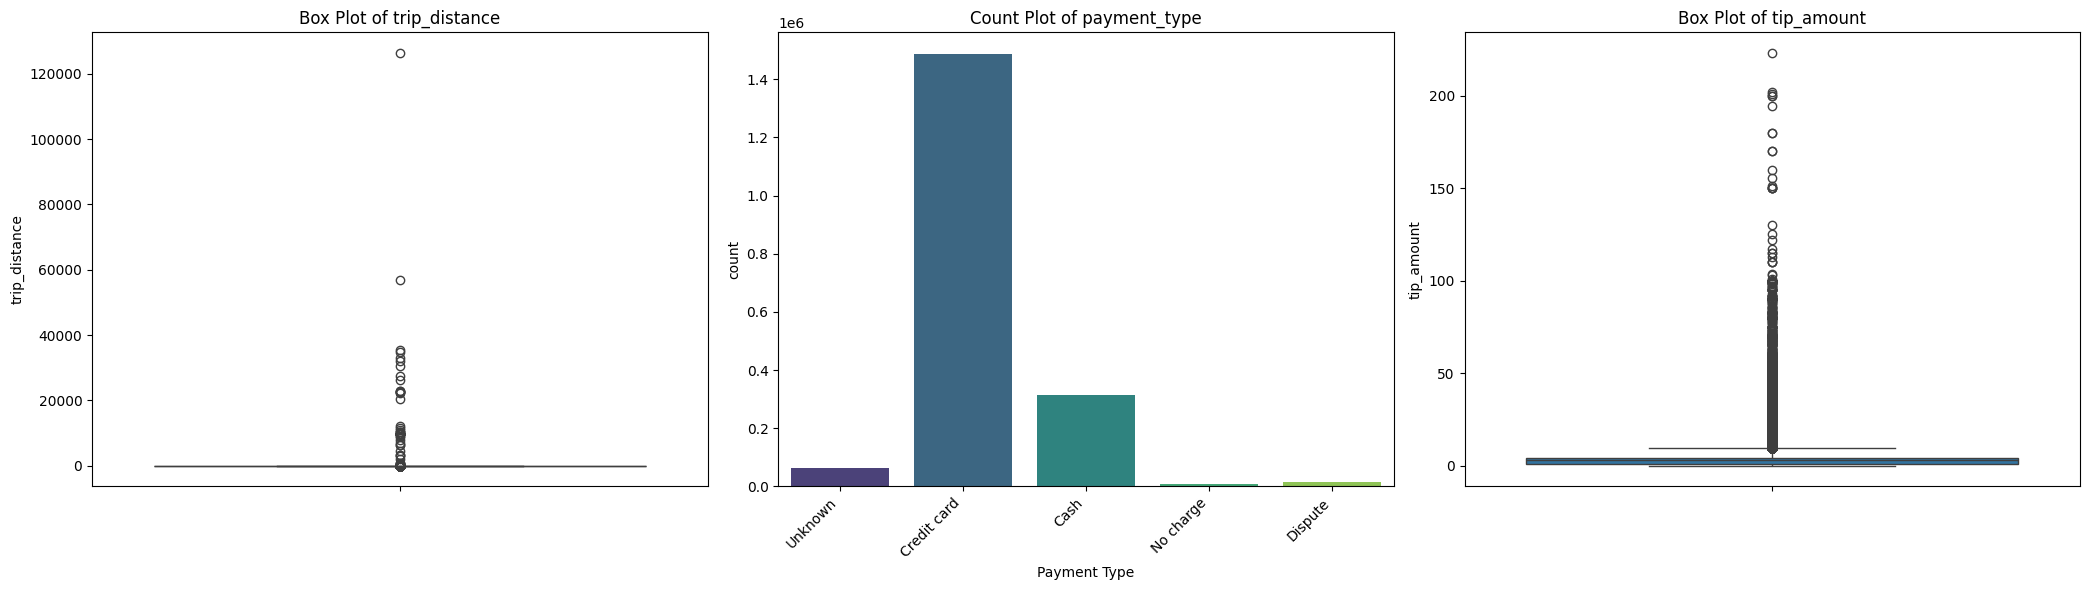

In [38]:
cols_to_plot = [
    'trip_distance',
    'payment_type',
    'tip_amount'
]

# Create a new figure with subplots for each column
fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(7 * len(cols_to_plot), 6))

# Ensure axes is an array even if there's only one subplot
if len(cols_to_plot) == 1:
    axes = [axes]

# Loop through each selected column and create the appropriate plot
for i, col in enumerate(cols_to_plot):
    if col == 'payment_type':
        # Use a countplot for categorical 'payment_type'
        sns.countplot(x=df[col], ax=axes[i], palette='viridis')
        axes[i].set_title(f'Count Plot of {col}')
        axes[i].set_xlabel('Payment Type')
        # Map numerical payment types to their descriptive labels for better readability
        payment_labels = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 0: 'Unknown'}
        current_ticks = sorted(df[col].unique())
        current_labels = [payment_labels.get(pt, str(pt)) for pt in current_ticks]
        axes[i].set_xticks(range(len(current_ticks)))
        axes[i].set_xticklabels(current_labels, rotation=45, ha='right')
    else:
        # Use a boxplot for numerical columns
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Box Plot of {col}')
        axes[i].set_ylabel(col)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

In [39]:
anomaly_condition_1 = (df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)
anomaly_condition_1.sum()

np.int64(35)

In [40]:
df.shape

(1889084, 18)

In [41]:
df.drop(df[anomaly_condition_1].index, inplace=True)

In [42]:
df.shape

(1889049, 18)

In [43]:
anomaly_condition_2 = (df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])
anomaly_condition_2.sum()

np.int64(63)

In [44]:
print(f'Before deletion: {df.shape}')
df.drop(df[anomaly_condition_2].index, inplace=True)
print(f'After deletion: {df.shape}')

Before deletion: (1889049, 18)
After deletion: (1888986, 18)


In [45]:
anomaly_condition_3 = (df['trip_distance'] > 250)
anomaly_condition_3.sum()

np.int64(46)

In [46]:
print(f'Before deletion: {df.shape}')
df.drop(df[anomaly_condition_3].index, inplace=True)
print(f'After deletion: {df.shape}')

Before deletion: (1888986, 18)
After deletion: (1888940, 18)


In [47]:
anomaly_condition_4 = (df['payment_type'] == 0)
anomaly_condition_4.mean()

np.float64(0.03416413438224613)

In [48]:
df.loc[df['payment_type'] == 0, 'payment_type'] = df['payment_type'].mode()[0]

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [49]:
df.shape

(1888940, 18)

In [50]:
# remove passenger_count > 6
df.drop(df[df['passenger_count'] > 6].index, inplace=True)

In [51]:
df.shape

(1888919, 18)

In [52]:
df['passenger_count'].value_counts()

,count
passenger_count,
1.0,1465943
2.0,276237
3.0,68767
4.0,38391
5.0,23775
6.0,15806


In [53]:
# Continue with outlier handling

(df['trip_distance']>4000).sum()

np.int64(0)

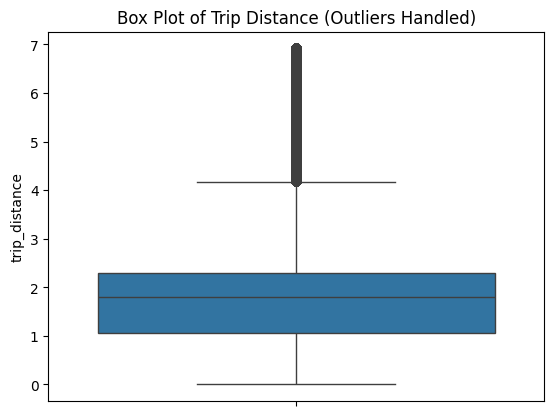

In [54]:
median_trip_distance = df['trip_distance'].median()
Q1_trip_distance = df['trip_distance'].quantile(0.25)
Q3_trip_distance = df['trip_distance'].quantile(0.75)
IQR_trip_distance = Q3_trip_distance - Q1_trip_distance

lower_bound_trip_distance = Q1_trip_distance - 1.5 * IQR_trip_distance
upper_bound_trip_distance = Q3_trip_distance + 1.5 * IQR_trip_distance

df.loc[(df['trip_distance'] < lower_bound_trip_distance) | (df['trip_distance'] > upper_bound_trip_distance), 'trip_distance'] = median_trip_distance

sns.boxplot(y=df['trip_distance'])
plt.title('Box Plot of Trip Distance (Outliers Handled)')
plt.show()

In [55]:
# Calculate the median for 'tip_amount'
median_tip_amount = df['tip_amount'].median()
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'tip_amount'
Q1 = df['tip_amount'].quantile(0.25)
Q3 = df['tip_amount'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1
# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Replace outliers (values outside the bounds) with the median
df.loc[(df['tip_amount'] < lower_bound) | (df['tip_amount'] > upper_bound), 'tip_amount'] = median_tip_amount

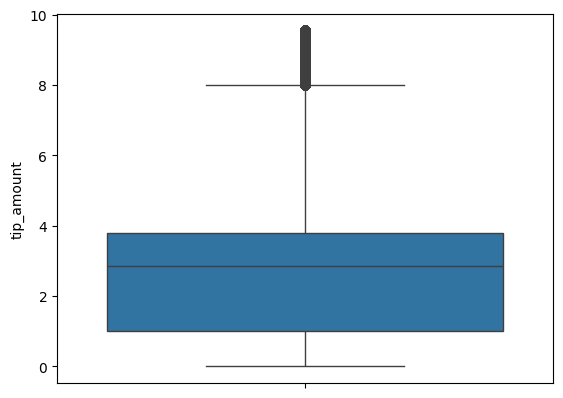

In [56]:
sns.boxplot(y=df['tip_amount'])
plt.show()

In [57]:
# Do any columns need standardising?
numerical_cols_for_standardization = [
    'fare_amount',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee',
    'extra'
]

print("Columns that could benefit from standardization due to varying scales:")
for col in numerical_cols_for_standardization:
    print(f"- {col}: Min={df[col].min():.2f}, Max={df[col].max():.2f}, Mean={df[col].mean():.2f}, Std={df[col].std():.2f}")


Columns that could benefit from standardization due to varying scales:
- fare_amount: Min=0.00, Max=143163.45, Mean=19.91, Std=105.72
- mta_tax: Min=0.00, Max=4.00, Mean=0.50, Std=0.05
- tip_amount: Min=0.00, Max=9.55, Mean=2.65, Std=2.05
- tolls_amount: Min=0.00, Max=143.00, Mean=0.60, Std=2.19
- improvement_surcharge: Min=0.00, Max=1.00, Mean=1.00, Std=0.03
- total_amount: Min=0.00, Max=143167.45, Mean=28.98, Std=106.60
- congestion_surcharge: Min=0.00, Max=2.50, Mean=2.31, Std=0.66
- airport_fee: Min=0.00, Max=1.75, Mean=0.14, Std=0.46
- extra: Min=0.00, Max=20.80, Mean=1.59, Std=1.83


In [58]:
median_extra = df['extra'].median()
Q1_extra = df['extra'].quantile(0.25)
Q3_extra = df['extra'].quantile(0.75)
IQR_extra = Q3_extra - Q1_extra

lower_bound_extra = Q1_extra - 1.5 * IQR_extra
upper_bound_extra = Q3_extra + 1.5 * IQR_extra

df.loc[(df['extra'] < lower_bound_extra) | (df['extra'] > upper_bound_extra), 'extra'] = median_extra

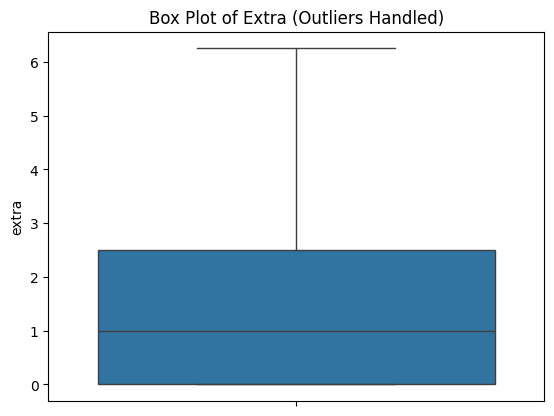

In [59]:
sns.boxplot(y=df['extra'])
plt.title('Box Plot of Extra (Outliers Handled)')
plt.show()

In [60]:
median_mta_tax = df['mta_tax'].median()
Q1_mta_tax = df['mta_tax'].quantile(0.25)
Q3_mta_tax = df['mta_tax'].quantile(0.75)
IQR_mta_tax = Q3_mta_tax - Q1_mta_tax

lower_bound_mta_tax = Q1_mta_tax - 1.5 * IQR_mta_tax
upper_bound_mta_tax = Q3_mta_tax + 1.5 * IQR_mta_tax

df.loc[(df['mta_tax'] < lower_bound_mta_tax) | (df['mta_tax'] > upper_bound_mta_tax), 'mta_tax'] = median_mta_tax

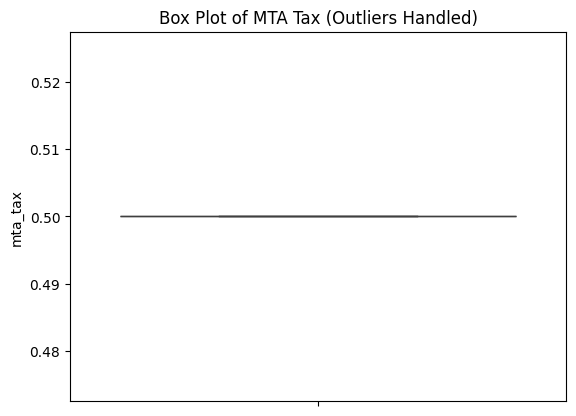

In [61]:
sns.boxplot(y=df['mta_tax'])
plt.title('Box Plot of MTA Tax (Outliers Handled)')
plt.show()

In [62]:
median_tolls_amount = df['tolls_amount'].median()
Q1_tolls_amount = df['tolls_amount'].quantile(0.25)
Q3_tolls_amount = df['tolls_amount'].quantile(0.75)
IQR_tolls_amount = Q3_tolls_amount - Q1_tolls_amount

lower_bound_tolls_amount = Q1_tolls_amount - 1.5 * IQR_tolls_amount
upper_bound_tolls_amount = Q3_tolls_amount + 1.5 * IQR_tolls_amount

df.loc[(df['tolls_amount'] < lower_bound_tolls_amount) | (df['tolls_amount'] > upper_bound_tolls_amount), 'tolls_amount'] = median_tolls_amount

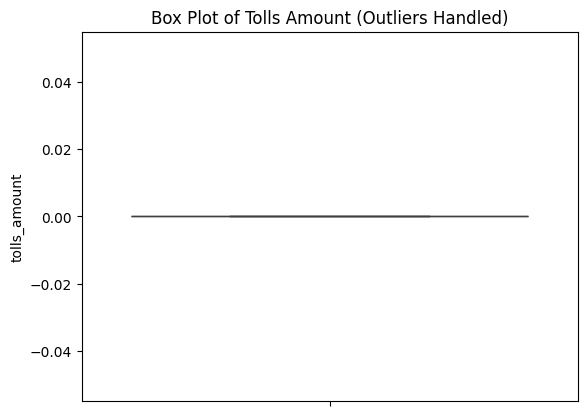

In [63]:
sns.boxplot(y=df['tolls_amount'])
plt.title('Box Plot of Tolls Amount (Outliers Handled)')
plt.show()

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [64]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

**Numerical columns:** VendorID, trip_distance, PULocationID, DOLocationID, trip_duration, pickup_hour

**Categorical columns:** passenger_count, RatecodeID, payment_type


**Datetime columns:** tpep_pickup_datetime, tpep_dropoff_datetime


##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [65]:
# Find and show the hourly trends in taxi pickups

df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['month'] = df['tpep_pickup_datetime'].dt.month_name()
trend_data = df.groupby('hour')['hour'].count()
print(trend_data)

hour
0      53481
1      35983
2      23716
3      15663
4      10522
5      11089
6      26228
7      51658
8      71191
9      80986
10     87404
11     95133
12    103303
13    106798
14    114132
15    117047
16    116791
17    127858
18    132922
19    118730
20    106008
21    106489
22     98345
23     77442
Name: hour, dtype: int64


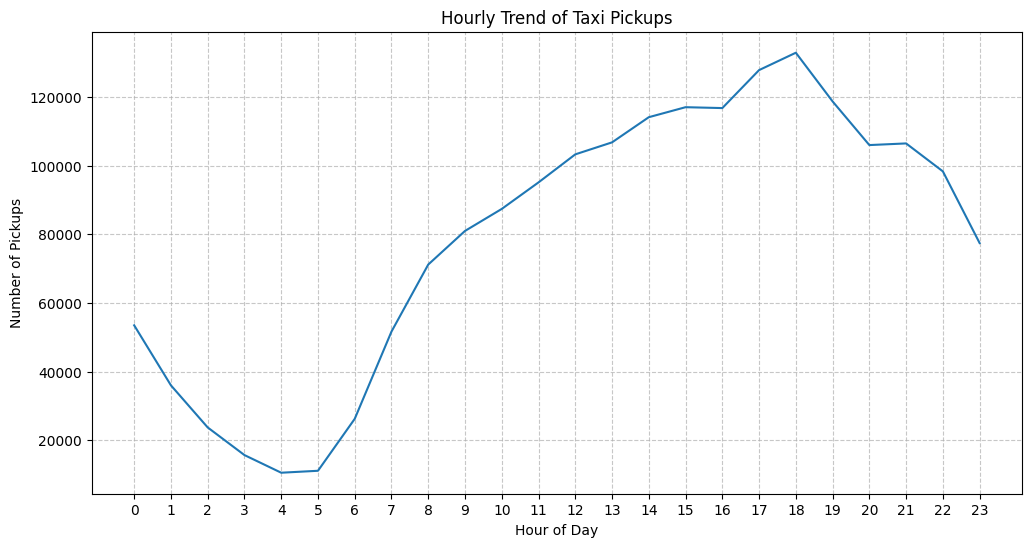

In [66]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=trend_data.index, y=trend_data.values)
plt.title('Hourly Trend of Taxi Pickups')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24)) # Ensure all hours are displayed on x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [67]:
# Find and show the daily trends in taxi pickups (days of the week)
weekly_trend_data = df.groupby('day_of_week')['day_of_week'].count()
print(weekly_trend_data)

day_of_week
Friday       281265
Monday       235093
Saturday     275055
Sunday       238520
Thursday     296621
Tuesday      272856
Wednesday    289509
Name: day_of_week, dtype: int64


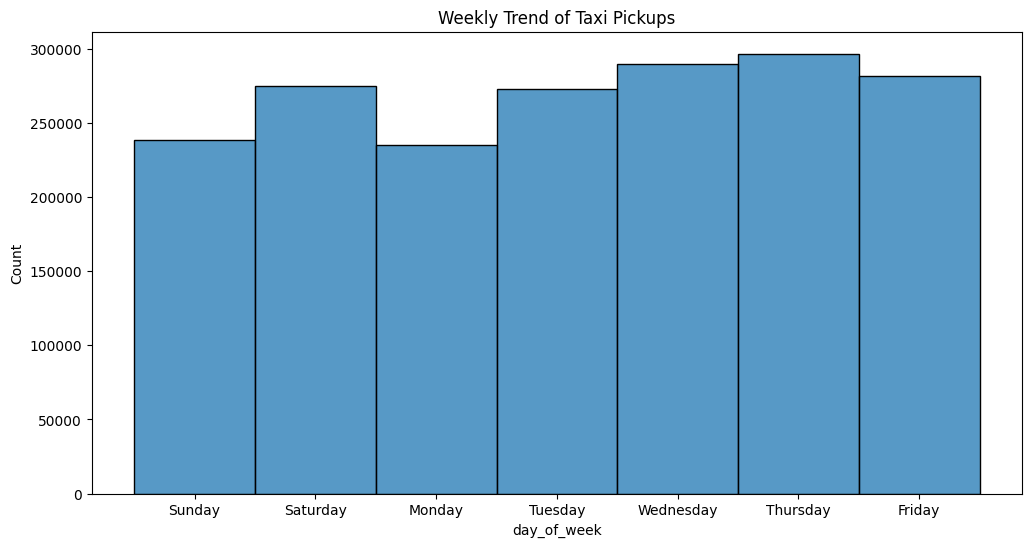

In [68]:
plt.figure(figsize=(12, 6))
plt.title('Weekly Trend of Taxi Pickups')
sns.histplot(data=df, x="day_of_week")
plt.show()

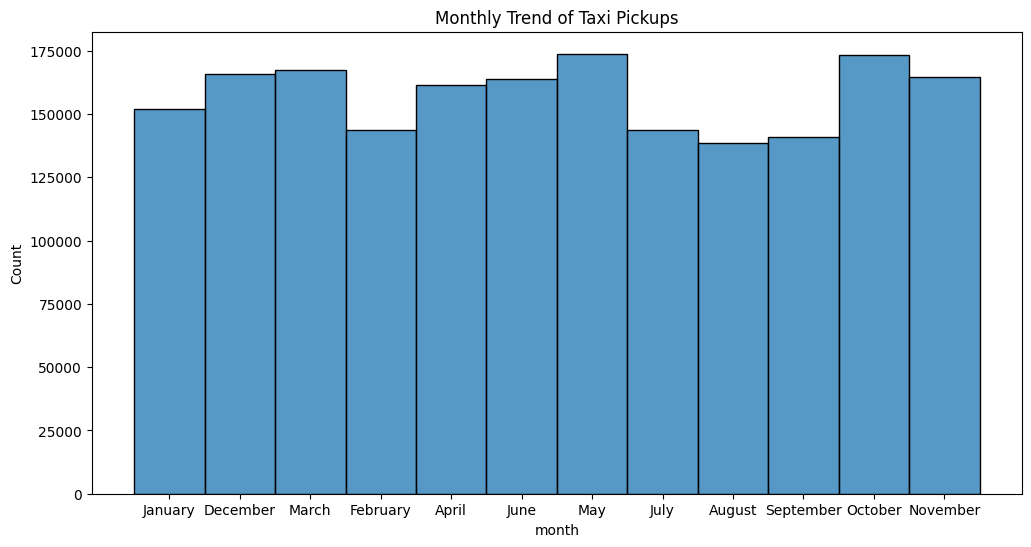

In [69]:
# Show the monthly trends in pickups

plt.figure(figsize=(12, 6))
plt.title('Monthly Trend of Taxi Pickups')
sns.histplot(data=df, x="month")
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [70]:
# Analyse the above parameters
df[['fare_amount','tip_amount','total_amount','trip_distance']].describe().T


,count,mean,std,min,25%,50%,75%,max
fare_amount,1888919.0,19.913843,105.720562,0.0,9.30,13.50,21.90,143163.45
tip_amount,1888919.0,2.654080,2.047351,0.0,1.00,2.85,3.80,9.55
total_amount,1888919.0,28.978383,106.597951,0.0,15.96,21.00,30.94,143167.45
trip_distance,1888919.0,1.913224,1.278918,0.0,1.05,1.80,2.30,6.92


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [71]:
# Create a df with non zero entries for the selected parameters.
df_non_zero = df[(df['fare_amount'] != 0) & (df['tip_amount'] != 0) & (df['total_amount'] != 0) & (df['trip_distance'] != 0)]
print(df_non_zero.shape)


(1445731, 21)


In [72]:
df_non_zero[['fare_amount','tip_amount','total_amount','trip_distance']].describe().T

,count,mean,std,min,25%,50%,75%,max
fare_amount,1445731.0,19.451167,17.125741,0.01,9.30,13.50,21.90,728.90
tip_amount,1445731.0,3.446962,1.647039,0.01,2.39,3.00,4.25,9.55
total_amount,1445731.0,29.655479,22.573516,4.51,16.80,21.84,31.44,762.45
trip_distance,1445731.0,1.966419,1.244296,0.01,1.10,1.80,2.38,6.92


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [73]:
# Group data by month and analyse monthly revenue

monthly_revenue = df_non_zero.groupby('month')['total_amount'].sum()
print(monthly_revenue)

month
April        3646175.77
August       3073052.35
December     3722941.51
February     3137773.89
January      3308306.14
July         3206444.76
June         3794260.24
March        3767843.58
May          4052873.83
November     3815114.23
October      4059933.59
September    3289125.02
Name: total_amount, dtype: float64


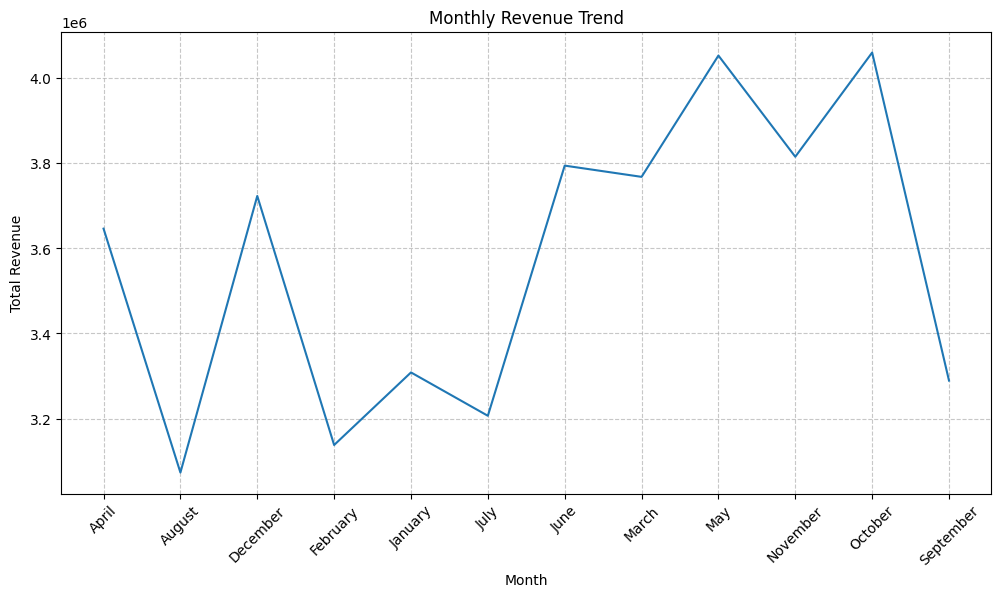

In [74]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [75]:
q1 = df_non_zero[df_non_zero['month'].isin(['January', 'February', 'March'])]['total_amount'].sum()/df_non_zero['total_amount'].sum()
q2 = df_non_zero[df_non_zero['month'].isin(['April','May','June'])]['total_amount'].sum()/df_non_zero['total_amount'].sum()
q3 = df_non_zero[df_non_zero['month'].isin(['July','August','September'])]['total_amount'].sum()/df_non_zero['total_amount'].sum()
q4 = df_non_zero[df_non_zero['month'].isin(['October','November','December'])]['total_amount'].sum()/df_non_zero['total_amount'].sum()

In [76]:
print(f"Proportion of Q1: {q1}")
print(f"Proportion of Q2: {q2}")
print(f"Proportion of Q3: {q3}")
print(f"Proportion of Q4: {q4}")

Proportion of Q1: 0.23823204173642204
Proportion of Q2: 0.26807275774138184
Proportion of Q3: 0.22318087286284405
Proportion of Q4: 0.27051432765935257


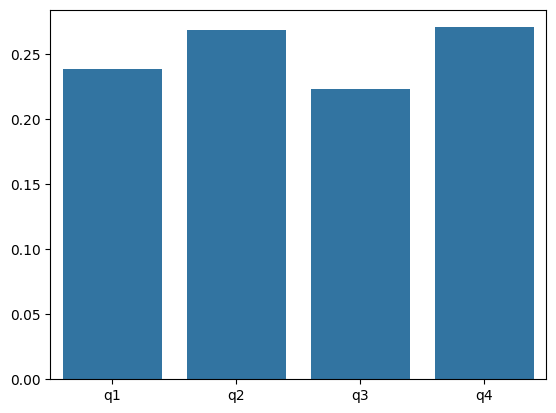

In [77]:
sns.barplot(x=['q1','q2','q3','q4'], y=[q1,q2,q3,q4])
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

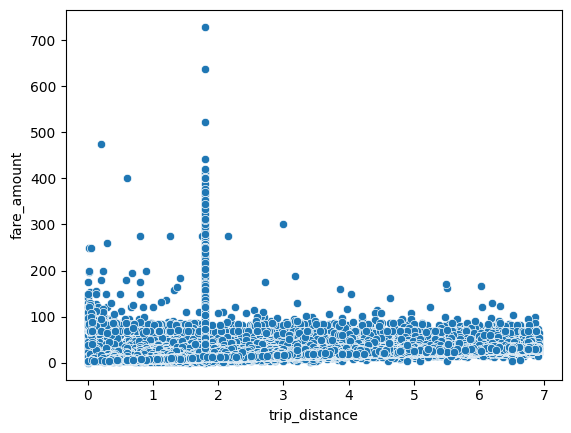

In [78]:
# Show how trip fare is affected by distance

sns.scatterplot(data=df_non_zero, x='trip_distance', y='fare_amount')
plt.show()


In [79]:
df_non_zero['trip_distance'].corr(df_non_zero['fare_amount'])

np.float64(0.28224678961871774)

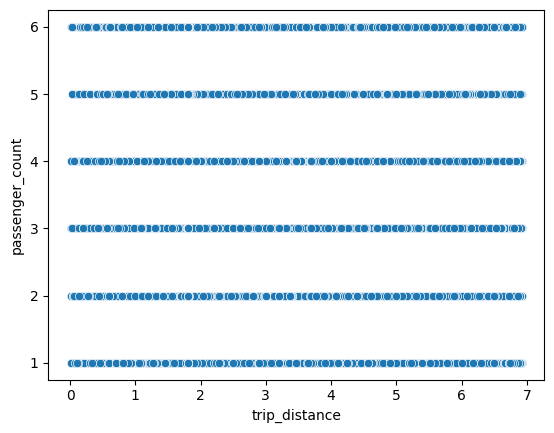

In [80]:
sns.scatterplot(data=df_non_zero, x='trip_distance', y='passenger_count')
plt.show()

In [81]:
df_non_zero['trip_distance'].corr(df_non_zero['passenger_count'])

np.float64(0.008028362552324378)

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [82]:
df_non_zero.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'hour', 'day_of_week', 'month'],
      dtype='object')

/tmp/ipykernel_9655/2606401091.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_zero['trip_duration'] = df_non_zero['tpep_dropoff_datetime'] - df_non_zero['tpep_pickup_datetime']
/tmp/ipykernel_9655/2606401091.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_zero['trip_duration_seconds'] = df_non_zero['trip_duration'].dt.total_seconds()


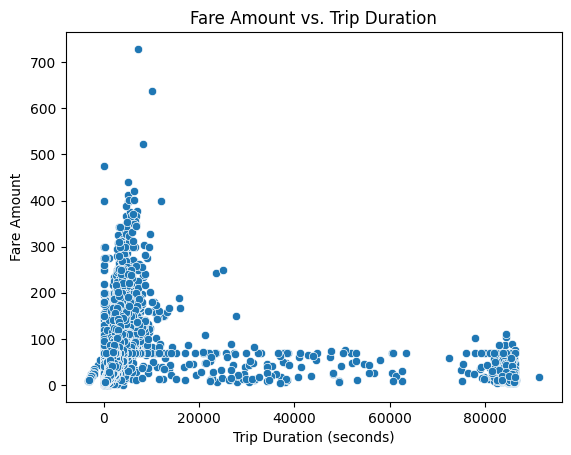

Correlation between fare_amount and trip_duration: 0.3323093188319888


In [83]:
# Show relationship between fare and trip duration

df_non_zero['trip_duration'] = df_non_zero['tpep_dropoff_datetime'] - df_non_zero['tpep_pickup_datetime']
df_non_zero['trip_duration_seconds'] = df_non_zero['trip_duration'].dt.total_seconds()
sns.scatterplot(data=df_non_zero, x='trip_duration_seconds', y='fare_amount')
plt.title('Fare Amount vs. Trip Duration')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Fare Amount')
plt.show()

correlation = df_non_zero['fare_amount'].corr(df_non_zero['trip_duration_seconds'])
print(f"Correlation between fare_amount and trip_duration: {correlation}")

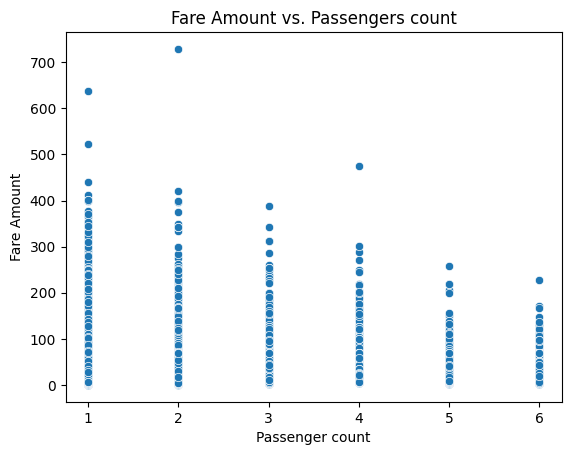

Correlation between fare_amount and passengers_count: 0.035866325198731716


In [84]:
# Show relationship between fare and number of passengers
sns.scatterplot(data=df_non_zero, x='passenger_count', y='fare_amount')
plt.title('Fare Amount vs. Passengers count')
plt.xlabel('Passenger count')
plt.ylabel('Fare Amount')
plt.show()

correlation = df_non_zero['fare_amount'].corr(df_non_zero['passenger_count'])
print(f"Correlation between fare_amount and passengers_count: {correlation}")


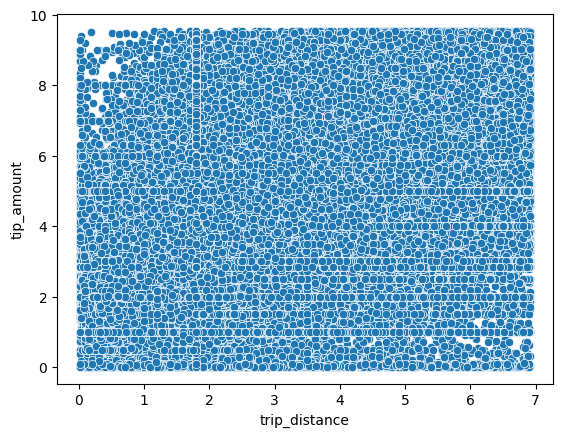

Correlation between trip_distance and tip_amount: 0.5332116824417185


In [85]:
# Show relationship between tip and trip distance
sns.scatterplot(data=df_non_zero, x='trip_distance', y='tip_amount')
plt.show()
correlation = df_non_zero['trip_distance'].corr(df_non_zero['tip_amount'])
print(f"Correlation between trip_distance and tip_amount: {correlation}")



**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

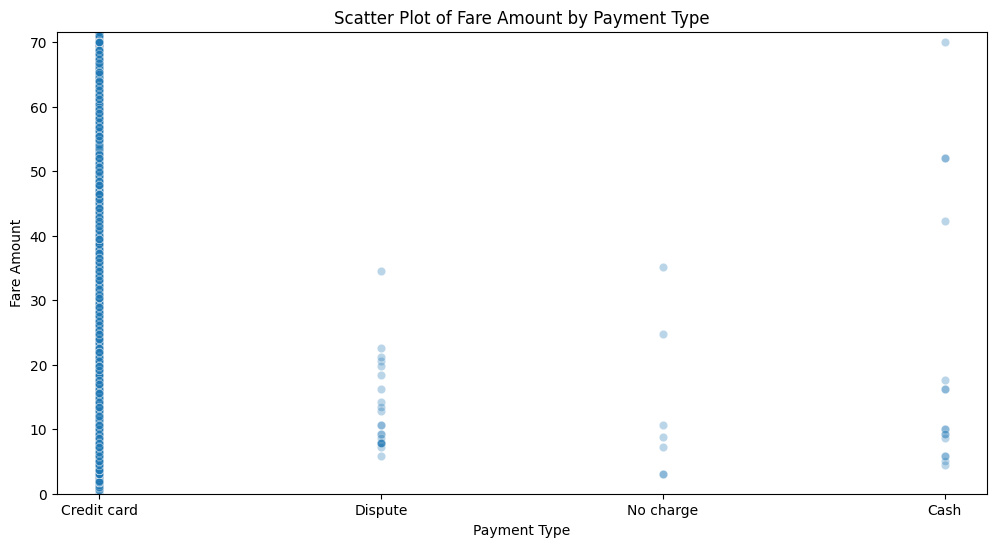

In [86]:
# Analyse the distribution of different payment types (payment_type).

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_non_zero, x='payment_type', y='fare_amount', alpha=0.3)
plt.title('Scatter Plot of Fare Amount by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Fare Amount')
# Limiting y-axis to better visualize the main distribution, as there are high outliers
plt.ylim(0, df_non_zero['fare_amount'].quantile(0.99))
plt.xticks(ticks=df_non_zero['payment_type'].unique(), labels={1: 'Credit card', 2: 'Cash', 4: 'Dispute', 3: 'No charge'}.values())
plt.show()

In [87]:
df['payment_type'].value_counts()

,count
payment_type,
1,1551188
2,315142
4,13611
3,8978


In [88]:
df_non_zero['payment_type'].value_counts()

,count
payment_type,
1,1445685
2,23
4,16
3,7


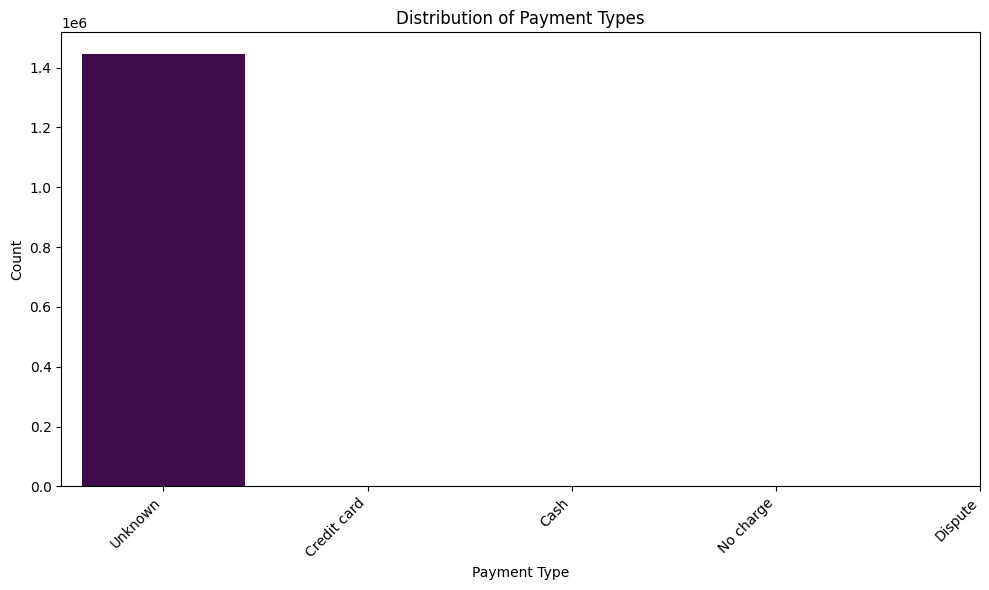

In [89]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_non_zero, x='payment_type', palette='viridis', hue='payment_type', legend=False)
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Count')
# Map numerical payment types to their descriptive labels for better readability
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Unknown', 'Credit card', 'Cash', 'No charge', 'Dispute'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [90]:
# !pip install geopandas
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [91]:
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file('taxi_zones.shp') # read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

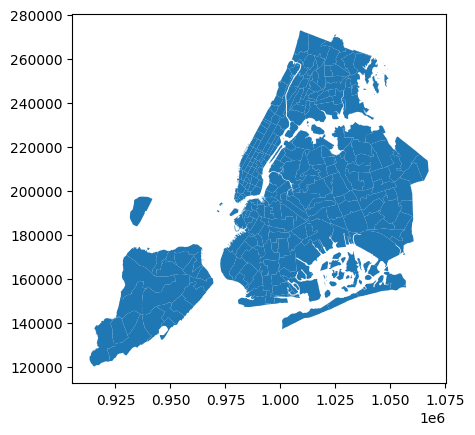

In [92]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [93]:
# Merge zones and trip records using locationID and PULocationID

merged = pd.merge(df_non_zero, zones, left_on='PULocationID', right_on='LocationID')
merged.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,month,trip_duration,trip_duration_seconds,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,161,237,1,7.90,...,January,0 days 00:05:05,305.0,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
1,2,2023-01-01 00:43:00,2023-01-01 01:01:00,1.0,1.80,1.0,66,107,1,25.64,...,January,0 days 00:18:00,1080.0,66,0.054633,0.000108,DUMBO/Vinegar Hill,66,Brooklyn,"POLYGON ((990055.507 196472.349, 990004.46 196..."
2,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,1.80,1.0,246,37,1,34.50,...,January,0 days 00:33:37,2017.0,246,0.069467,0.000281,West Chelsea/Hudson Yards,246,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216..."
3,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2.0,1.59,1.0,79,164,1,11.40,...,January,0 days 00:10:31,631.0,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
4,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1.0,3.16,1.0,79,256,1,19.10,...,January,0 days 00:15:53,953.0,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [94]:
# Group data by location and calculate the number of trips

groupby_location = merged.groupby('LocationID').size().reset_index(name='total_trips')


In [95]:
groupby_location

,LocationID,total_trips
0,1,37
1,2,2
2,4,1690
3,6,1
4,7,356
...,...,...
227,259,1
228,260,111
229,261,7077
230,262,20448


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [96]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(groupby_location, on='LocationID', how='left')
zones_with_trips['total_trips'] = zones_with_trips['total_trips'].fillna(0).astype(int)
display(zones_with_trips.head())

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,total_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",37
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1690
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

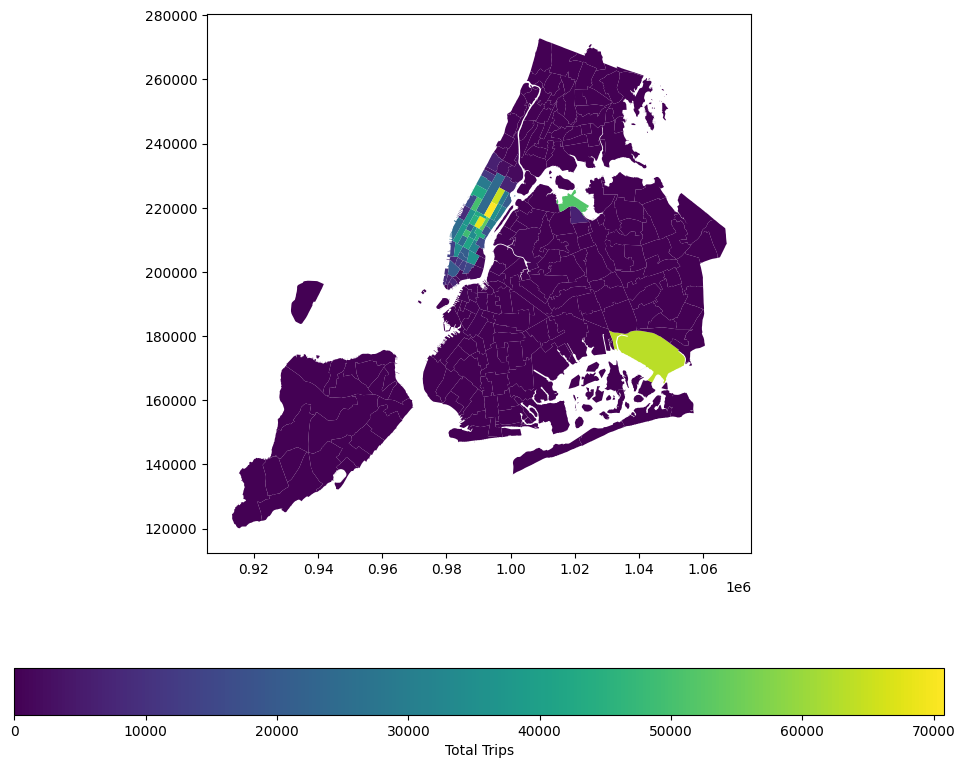

In [97]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
zones_with_trips.plot(column='total_trips', ax=ax, legend=True, legend_kwds={'label': "Total Trips", 'orientation': "horizontal"})
plt.show()


In [98]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trips.sort_values(by='total_trips', ascending=False)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,total_trips
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",70823
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",68447
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",65021
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",63598
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",53214
...,...,...,...,...,...,...,...,...
26,27,0.202509,0.001341,Breezy Point/Fort Tilden/Riis Beach,27,Queens,"POLYGON ((1021692.969 147138.664, 1021883.624 ...",0
31,32,0.054267,0.000151,Bronxdale,32,Bronx,"POLYGON ((1023302.25 251923.918, 1022481.96 25...",0
29,30,0.094510,0.000146,Broad Channel,30,Queens,"POLYGON ((1034013.272 163473.152, 1034866.459 ...",0
244,245,0.095983,0.000466,West Brighton,245,Staten Island,"POLYGON ((957085.564 172591.26, 957142.385 172...",0


In [99]:
zones_with_trips[zones_with_trips['total_trips'] == 0].count()

,0
OBJECTID,30
Shape_Leng,30
Shape_Area,30
zone,30
LocationID,30
borough,30
geometry,30
total_trips,30


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [100]:
merged_df = pd.merge(df_non_zero, zones_with_trips, left_on='PULocationID', right_on='LocationID')
merged_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,trip_duration,trip_duration_seconds,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,total_trips
0,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,161,237,1,7.90,...,0 days 00:05:05,305.0,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",68447
1,2,2023-01-01 00:43:00,2023-01-01 01:01:00,1.0,1.80,1.0,66,107,1,25.64,...,0 days 00:18:00,1080.0,66,0.054633,0.000108,DUMBO/Vinegar Hill,66,Brooklyn,"POLYGON ((990055.507 196472.349, 990004.46 196...",392
2,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,1.80,1.0,246,37,1,34.50,...,0 days 00:33:37,2017.0,246,0.069467,0.000281,West Chelsea/Hudson Yards,246,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216...",24819
3,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2.0,1.59,1.0,79,164,1,11.40,...,0 days 00:10:31,631.0,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20...",35923
4,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1.0,3.16,1.0,79,256,1,19.10,...,0 days 00:15:53,953.0,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20...",35923


In [101]:
merged_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'hour', 'day_of_week', 'month',
       'trip_duration', 'trip_duration_seconds', 'OBJECTID', 'Shape_Leng',
       'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry',
       'total_trips'],
      dtype='object')

In [102]:
# Find routes which have the slowest speeds at different times of the day

merged_df['speed'] = merged_df['trip_distance'] / merged_df['trip_duration_seconds']
merged_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,trip_duration_seconds,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,total_trips,speed
0,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,161,237,1,7.90,...,305.0,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",68447,0.004066
1,2,2023-01-01 00:43:00,2023-01-01 01:01:00,1.0,1.80,1.0,66,107,1,25.64,...,1080.0,66,0.054633,0.000108,DUMBO/Vinegar Hill,66,Brooklyn,"POLYGON ((990055.507 196472.349, 990004.46 196...",392,0.001667
2,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,1.80,1.0,246,37,1,34.50,...,2017.0,246,0.069467,0.000281,West Chelsea/Hudson Yards,246,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216...",24819,0.000892
3,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2.0,1.59,1.0,79,164,1,11.40,...,631.0,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20...",35923,0.002520
4,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1.0,3.16,1.0,79,256,1,19.10,...,953.0,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20...",35923,0.003316


In [103]:
route_speed = merged_df.groupby(['PULocationID', 'DOLocationID', 'hour'])['speed'].mean().reset_index()
slowest_routes = route_speed.sort_values(by='speed').head(10)
display(slowest_routes)

,PULocationID,DOLocationID,hour,speed
33352,114,120,1,-0.002490
33252,114,106,1,-0.001361
75223,198,36,1,-0.000539
96985,243,264,17,0.000002
6210,43,10,10,0.000006
7719,45,45,10,0.000017
63859,162,162,4,0.000018
3044,22,22,15,0.000020
92138,237,57,10,0.000021
95144,238,257,16,0.000021


In [104]:
merged_df[['PULocationID','total_trips']].drop_duplicates().sort_values(by='total_trips', ascending=False).head(10)

,PULocationID,total_trips
27,237,70823
0,161,68447
47,236,65021
5,132,63598
25,162,53214
109,138,51661
9,142,49868
92,186,48951
564,230,44969
14,170,43839


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

hour
0      40640
1      27206
2      17503
3      11038
4       6671
5       7166
6      18554
7      39326
8      55459
9      61552
10     64350
11     69845
12     75858
13     78046
14     83994
15     86646
16     87515
17     98571
18    104074
19     93315
20     83701
21     84595
22     77868
23     59783
Name: hour, dtype: int64
The busiest hour is 18:00 with 104074 trips.


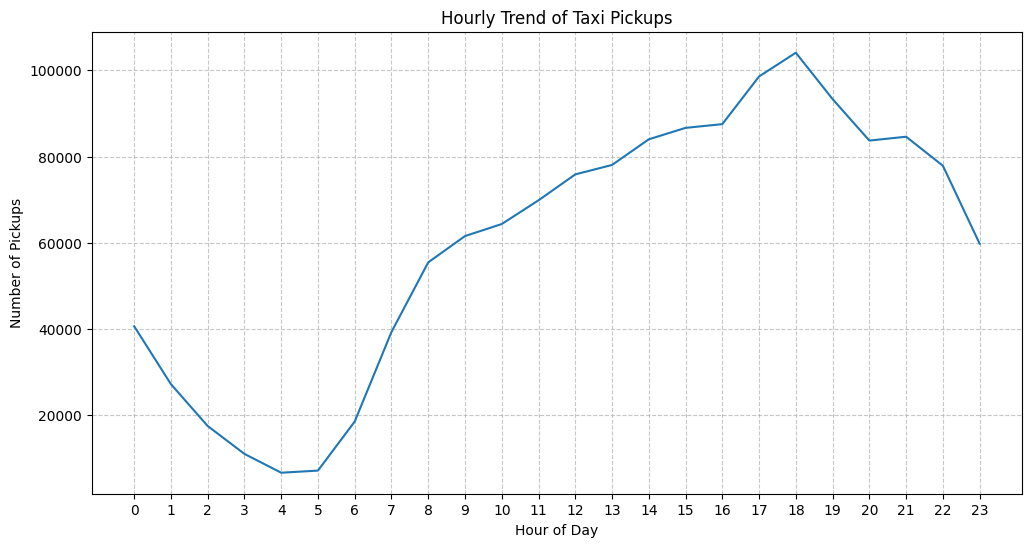

In [105]:
trend_data = merged_df.groupby('hour')['hour'].count()
print(trend_data)

busiest_hour = trend_data.idxmax()
max_trips = trend_data.max()
print(f"The busiest hour is {busiest_hour}:00 with {max_trips} trips.")

plt.figure(figsize=(12, 6))
sns.lineplot(x=trend_data.index, y=trend_data.values)
plt.title('Hourly Trend of Taxi Pickups')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24)) # Ensure all hours are displayed on x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [106]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05


In [107]:
# Find the five busiest hours and their actual number of trips
busiest_hours_sampled = trend_data.nlargest(5)
actual_busiest_hours = busiest_hours_sampled / sample_fraction

print("Top 5 busiest hours and their actual number of trips:")
print(actual_busiest_hours)


Top 5 busiest hours and their actual number of trips:
hour
18    2081480.0
17    1971420.0
19    1866300.0
16    1750300.0
15    1732920.0
Name: hour, dtype: float64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

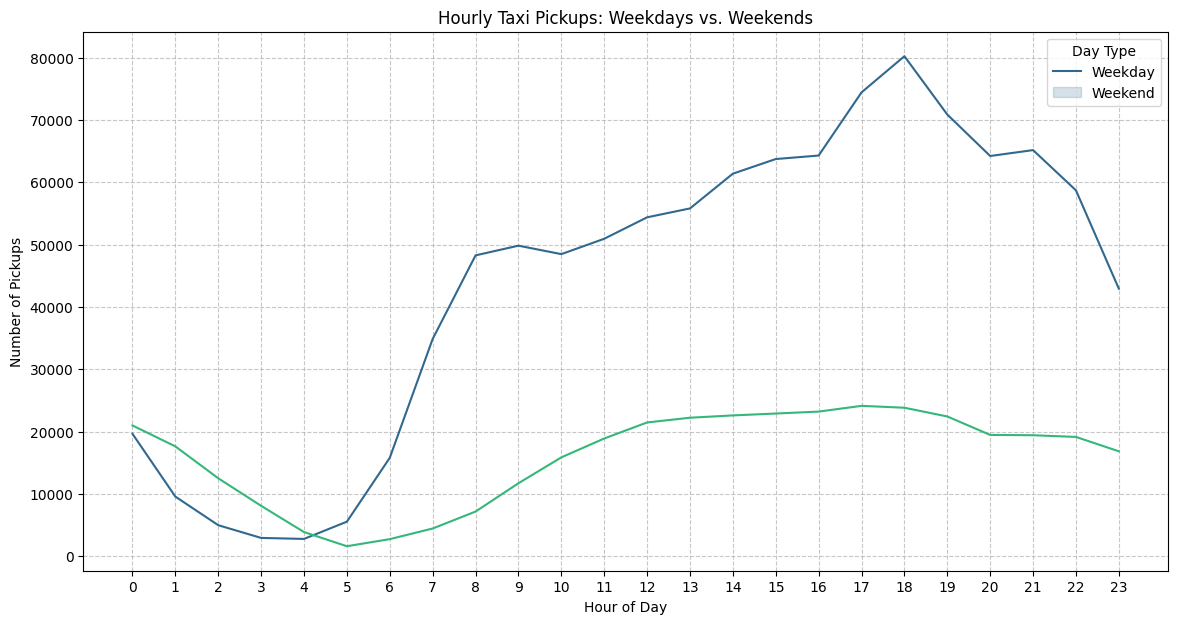

In [108]:
# Compare traffic trends for the week days and weekends

merged_df['is_weekend'] = merged_df['tpep_pickup_datetime'].dt.dayofweek.isin([5, 6]) # Saturday and Sunday are 5 and 6

# Group data by hour and 'is_weekend' to get trip counts
hourly_weekend_weekday_trend = merged_df.groupby(['hour', 'is_weekend'])['tpep_pickup_datetime'].count().unstack()

# Reshape the data from wide to long format
hourly_weekend_weekday_trend_long = hourly_weekend_weekday_trend.reset_index().melt(id_vars='hour', var_name='Day Type', value_name='Number of Pickups')

# Plot the trends using the reshaped DataFrame
plt.figure(figsize=(14, 7))
sns.lineplot(data=hourly_weekend_weekday_trend_long, x='hour', y='Number of Pickups', hue='Day Type', palette='viridis')
plt.title('Hourly Taxi Pickups: Weekdays vs. Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Day Type', labels=['Weekday', 'Weekend'])
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [109]:
# Find top 10 pickup and dropoff zones

# Calculate hourly pickups for each zone
hourly_pickups = merged_df.groupby(['PULocationID', 'hour']).size().reset_index(name='pickup_count')

# Calculate hourly dropoffs for each zone
hourly_dropoffs = merged_df.groupby(['DOLocationID', 'hour']).size().reset_index(name='dropoff_count')

# Get total pickups per zone to find top 10
total_pickups_per_zone = hourly_pickups.groupby('PULocationID')['pickup_count'].sum().sort_values(ascending=False)
top_10_pickup_zones = total_pickups_per_zone.head(10).index.tolist()

# Get total dropoffs per zone to find top 10
total_dropoffs_per_zone = hourly_dropoffs.groupby('DOLocationID')['dropoff_count'].sum().sort_values(ascending=False)
top_10_dropoff_zones = total_dropoffs_per_zone.head(10).index.tolist()

print("Top 10 Pickup Zones:", top_10_pickup_zones)
print("Top 10 Dropoff Zones:", top_10_dropoff_zones)

Top 10 Pickup Zones: [237, 161, 236, 132, 162, 138, 142, 186, 230, 170]
Top 10 Dropoff Zones: [236, 237, 161, 170, 239, 142, 162, 141, 230, 68]


### Hourly Pickup Trends for Top 10 Pickup Zones

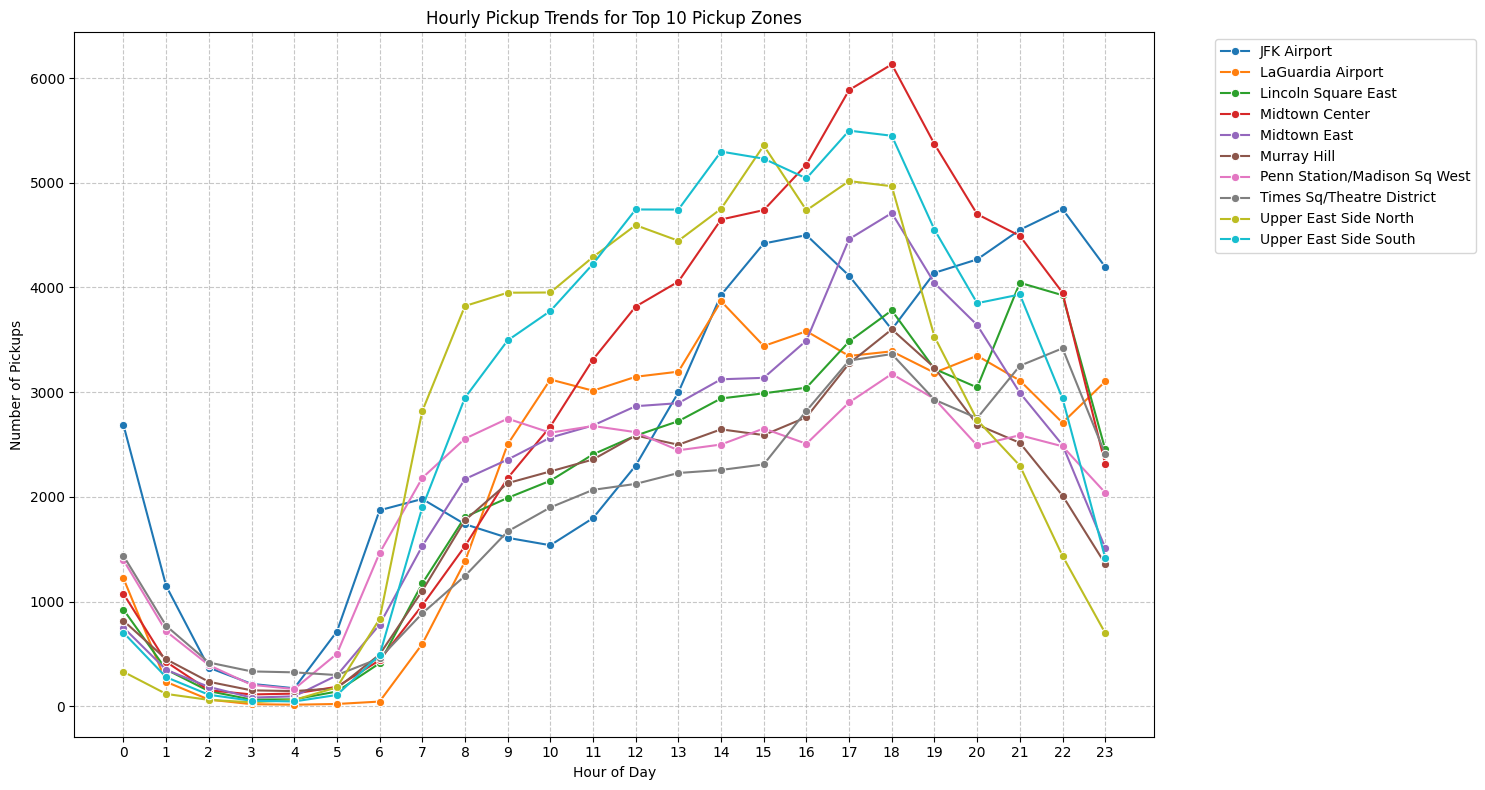

In [110]:
# Filter hourly pickups for top 10 zones
top_pickup_zones_data = hourly_pickups[hourly_pickups['PULocationID'].isin(top_10_pickup_zones)]

# Merge with zones DataFrame to get zone names
top_pickup_zones_data = pd.merge(top_pickup_zones_data, zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')

plt.figure(figsize=(15, 8))
sns.lineplot(data=top_pickup_zones_data, x='hour', y='pickup_count', hue='zone', marker='o')
plt.title('Hourly Pickup Trends for Top 10 Pickup Zones')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Hourly Dropoff Trends for Top 10 Dropoff Zones

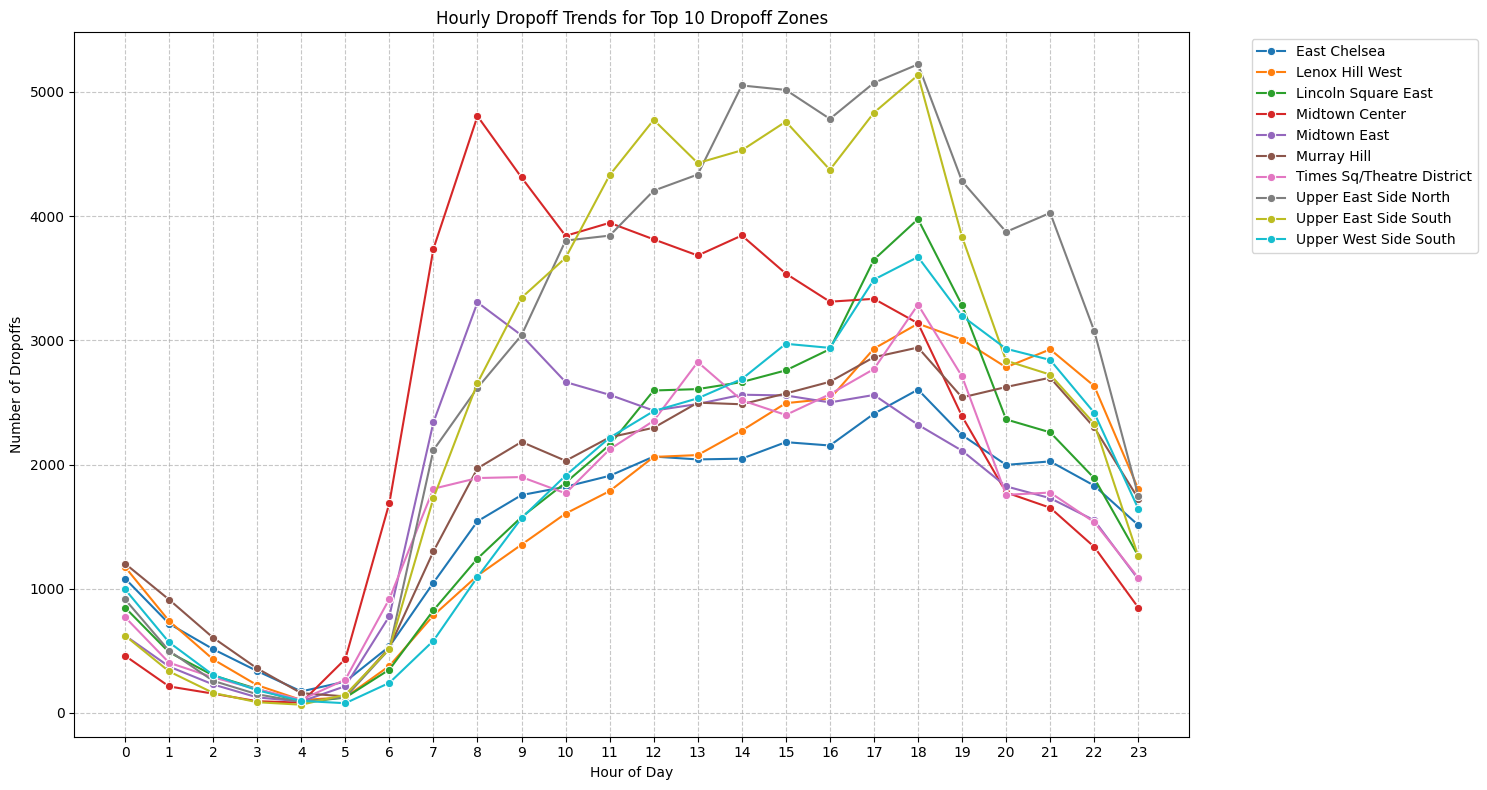

In [111]:
# Filter hourly dropoffs for top 10 zones
top_dropoff_zones_data = hourly_dropoffs[hourly_dropoffs['DOLocationID'].isin(top_10_dropoff_zones)]

# Merge with zones DataFrame to get zone names
top_dropoff_zones_data = pd.merge(top_dropoff_zones_data, zones[['LocationID', 'zone']], left_on='DOLocationID', right_on='LocationID', how='left')

plt.figure(figsize=(15, 8))
sns.lineplot(data=top_dropoff_zones_data, x='hour', y='dropoff_count', hue='zone', marker='o')
plt.title('Hourly Dropoff Trends for Top 10 Dropoff Zones')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Dropoffs')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [112]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Calculate total pickups and dropoffs per zone
total_pickups = merged_df.groupby('PULocationID').size().reset_index(name='total_pickups')
total_dropoffs = merged_df.groupby('DOLocationID').size().reset_index(name='total_dropoffs')

# Merge these into a single DataFrame
zone_activity = pd.merge(total_pickups, total_dropoffs, left_on='PULocationID', right_on='DOLocationID', how='outer')
zone_activity.rename(columns={'PULocationID': 'LocationID'}, inplace=True)
zone_activity.drop('DOLocationID', axis=1, inplace=True)

# Fill NaN values with 0 (for zones with only pickups or only dropoffs)
zone_activity['total_pickups'] = zone_activity['total_pickups'].fillna(0)
zone_activity['total_dropoffs'] = zone_activity['total_dropoffs'].fillna(0)

# Calculate the pickup/dropoff ratio, handling division by zero
zone_activity['pickup_dropoff_ratio'] = zone_activity.apply(lambda row: row['total_pickups'] / row['total_dropoffs'] if row['total_dropoffs'] > 0 else (row['total_pickups'] if row['total_pickups'] > 0 else 0), axis=1)

# Merge with zones DataFrame to get zone names
zone_activity = pd.merge(zone_activity, zones[['LocationID', 'zone']], on='LocationID', how='left')

# Sort for highest ratios
highest_ratios = zone_activity.sort_values(by='pickup_dropoff_ratio', ascending=False).head(10)

# Sort for lowest ratios (excluding zones with zero pickups or zero dropoffs where ratio is not meaningful)
lowest_ratios = zone_activity[zone_activity['total_pickups'] > 0].sort_values(by='pickup_dropoff_ratio', ascending=True).head(10)

print("Top 10 Zones with Highest Pickup/Dropoff Ratio:")
display(highest_ratios[['zone', 'total_pickups', 'total_dropoffs', 'pickup_dropoff_ratio']])

print("\nTop 10 Zones with Lowest Pickup/Dropoff Ratio (excluding zero pickups):")
display(lowest_ratios[['zone', 'total_pickups', 'total_dropoffs', 'pickup_dropoff_ratio']])

Top 10 Zones with Highest Pickup/Dropoff Ratio:


,zone,total_pickups,total_dropoffs,pickup_dropoff_ratio
70,East Elmhurst,6428.0,473.0,13.589852
127,JFK Airport,63598.0,14918.0,4.263172
133,LaGuardia Airport,51661.0,20011.0,2.581630
194,Rikers Island,2.0,0.0,2.000000
1,Jamaica Bay,2.0,0.0,2.000000
202,Saint Michaels Cemetery/Woodside,12.0,7.0,1.714286
181,Penn Station/Madison Sq West,48951.0,29907.0,1.636774
109,Greenwich Village South,20277.0,14617.0,1.387220
42,Central Park,24227.0,17494.0,1.384875
244,West Village,34551.0,25846.0,1.336803



Top 10 Zones with Lowest Pickup/Dropoff Ratio (excluding zero pickups):


,zone,total_pickups,total_dropoffs,pickup_dropoff_ratio
144,Madison,1.0,122.0,0.008197
0,Newark Airport,37.0,4248.0,0.008710
37,Cambria Heights,1.0,107.0,0.009346
14,Bay Terrace/Fort Totten,1.0,87.0,0.011494
18,Bellerose,1.0,78.0,0.012821
160,Midwood,3.0,233.0,0.012876
254,Woodlawn/Wakefield,1.0,75.0,0.013333
17,Bedford Park,1.0,67.0,0.014925
166,Murray Hill-Queens,2.0,128.0,0.015625
249,Williamsbridge/Olinville,1.0,64.0,0.015625


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [114]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Define night hours (11 PM to 5 AM)
night_hours = [23, 0, 1, 2, 3, 4, 5]

# Filter the merged_df for night hours
night_time_df = merged_df[merged_df['hour'].isin(night_hours)]

# Calculate pickups during night hours per zone
night_pickups = night_time_df.groupby('PULocationID').size().reset_index(name='night_pickup_count')

# Calculate dropoffs during night hours per zone
night_dropoffs = night_time_df.groupby('DOLocationID').size().reset_index(name='night_dropoff_count')

# Merge with zones DataFrame to get zone names
night_pickups = pd.merge(night_pickups, zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')
night_dropoffs = pd.merge(night_dropoffs, zones[['LocationID', 'zone']], left_on='DOLocationID', right_on='LocationID', how='left')

# Get top 10 night pickup zones
top_10_night_pickups = night_pickups.sort_values(by='night_pickup_count', ascending=False).head(10)

# Get top 10 night dropoff zones
top_10_night_dropoffs = night_dropoffs.sort_values(by='night_dropoff_count', ascending=False).head(10)

print("\nTop 10 zones with highest pickup traffic during night hours (11 PM to 5 AM):")
display(top_10_night_pickups[['zone', 'night_pickup_count']])

print("\nTop 10 zones with highest dropoff traffic during night hours (11 PM to 5 AM):")
display(top_10_night_dropoffs[['zone', 'night_dropoff_count']])


Top 10 zones with highest pickup traffic during night hours (11 PM to 5 AM):


,zone,night_pickup_count
52,East Village,13173
178,West Village,10732
85,JFK Airport,9500
99,Lower East Side,8243
29,Clinton East,8201
72,Greenwich Village South,7440
163,Times Sq/Theatre District,5985
127,Penn Station/Madison Sq West,5415
113,Midtown South,4905
42,East Chelsea,4806



Top 10 zones with highest dropoff traffic during night hours (11 PM to 5 AM):


,zone,night_dropoff_count
78,East Village,6864
46,Clinton East,5217
164,Murray Hill,5095
102,Gramercy,4883
135,Lenox Hill West,4601
67,East Chelsea,4587
255,Yorkville West,4371
241,West Village,4177
231,Upper West Side South,3869
228,Upper East Side North,3786


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [115]:
# Filter for night hours (11 PM to 5 AM)

night_hours = [23, 0, 1, 2, 3, 4, 5]
day_hours = [h for h in range(24) if h not in night_hours]

# Calculate total revenue for night hours
night_revenue = merged_df[merged_df['hour'].isin(night_hours)]['total_amount'].sum()

# Calculate total revenue for day hours
day_revenue = merged_df[merged_df['hour'].isin(day_hours)]['total_amount'].sum()

# Calculate total revenue for the entire period
total_revenue = night_revenue + day_revenue

# Calculate revenue share
night_revenue_share = (night_revenue / total_revenue) * 100
day_revenue_share = (day_revenue / total_revenue) * 100

print(f"Nighttime Revenue Share: {night_revenue_share:.2f}%")
print(f"Daytime Revenue Share: {day_revenue_share:.2f}%")

Nighttime Revenue Share: 12.05%
Daytime Revenue Share: 87.95%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [117]:
# Analyse the fare per mile per passenger for different passenger counts

df_non_zero['fare_per_mile'] = df_non_zero['fare_amount'] / df_non_zero['trip_distance']
df_non_zero['fare_per_mile_per_passenger'] = df_non_zero['fare_per_mile'] / df_non_zero['passenger_count']

average_fare_per_mile_per_passenger = df_non_zero.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()

print("Average fare per mile per passenger for different passenger counts:")
display(average_fare_per_mile_per_passenger)

Average fare per mile per passenger for different passenger counts:


/tmp/ipykernel_9655/3713702350.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_zero['fare_per_mile'] = df_non_zero['fare_amount'] / df_non_zero['trip_distance']
/tmp/ipykernel_9655/3713702350.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_zero['fare_per_mile_per_passenger'] = df_non_zero['fare_per_mile'] / df_non_zero['passenger_count']


,passenger_count,fare_per_mile_per_passenger
0,1.0,12.415541
1,2.0,7.324027
2,3.0,4.743307
3,4.0,5.096074
4,5.0,2.191935
5,6.0,1.816143


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [119]:
# Compare the average fare per mile for different days and for different times of the day

average_fare_per_mile_hourly = df_non_zero.groupby('hour')['fare_per_mile'].mean().reset_index()
print("Average fare per mile by hour of the day:")
display(average_fare_per_mile_hourly)

Average fare per mile by hour of the day:


,hour,fare_per_mile
0,0,11.329661
1,1,11.161286
2,2,9.963727
3,3,10.125418
4,4,17.430327
5,5,21.807374
6,6,16.251928
7,7,12.861857
8,8,12.009674
9,9,12.272289


In [120]:
average_fare_per_mile_daily = df_non_zero.groupby('day_of_week')['fare_per_mile'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index()
print("\nAverage fare per mile by day of the week:")
display(average_fare_per_mile_daily)


Average fare per mile by day of the week:


,day_of_week,fare_per_mile
0,Monday,13.327441
1,Tuesday,12.677672
2,Wednesday,12.435645
3,Thursday,12.952950
4,Friday,12.725893
5,Saturday,11.921971
6,Sunday,14.674452


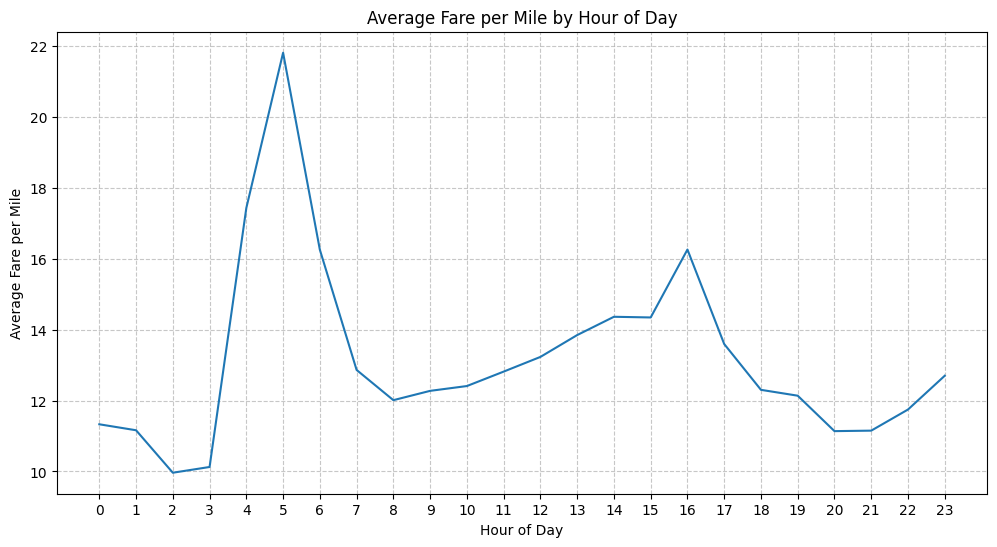

In [121]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=average_fare_per_mile_hourly, x='hour', y='fare_per_mile')
plt.title('Average Fare per Mile by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare per Mile')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_9655/1732867568.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_fare_per_mile_daily, x='day_of_week', y='fare_per_mile', palette='viridis')


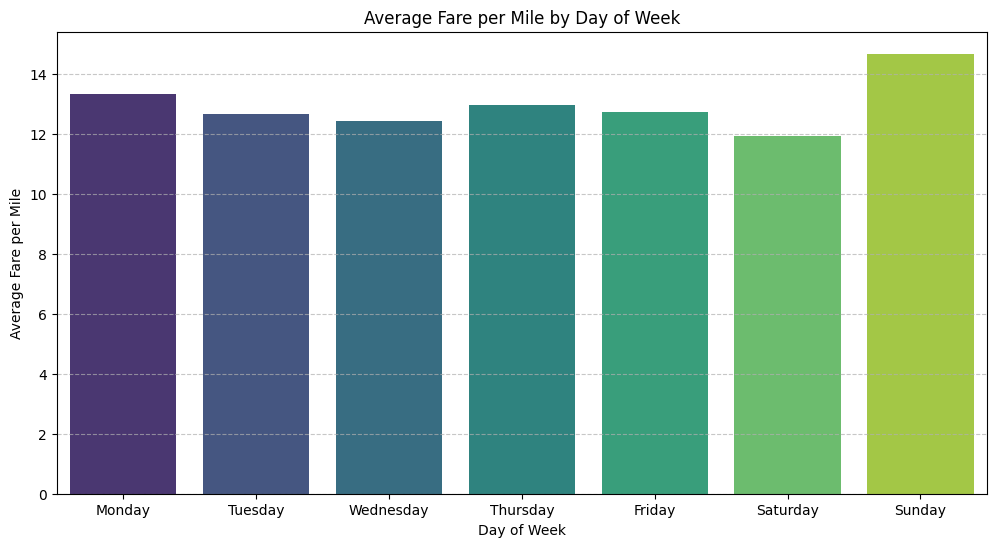

In [122]:
plt.figure(figsize=(12, 6))
sns.barplot(data=average_fare_per_mile_daily, x='day_of_week', y='fare_per_mile', palette='viridis')
plt.title('Average Fare per Mile by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Fare per Mile')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [123]:
# Compare fare per mile for different vendors

vendor_hourly_fare_per_mile = df_non_zero.groupby(['VendorID', 'hour'])['fare_per_mile'].mean().unstack()
print("Average fare per mile by Vendor ID and hour of the day:")
display(vendor_hourly_fare_per_mile)

Average fare per mile by Vendor ID and hour of the day:


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
VendorID,,,,,,,,,,,,,,,,,,,,,
1,9.723320,9.064297,8.415704,8.519896,12.359380,15.750384,11.534473,10.200903,10.351527,10.754763,...,12.061802,11.904042,11.856583,11.028877,10.321060,10.157813,9.911955,9.851017,9.930945,10.258207
2,11.786983,11.760735,10.419575,10.568353,18.745228,23.709742,18.019805,13.887631,12.638179,12.846386,...,15.203797,15.228897,17.849981,14.493063,12.977849,12.791651,11.531913,11.545821,12.283232,13.414902


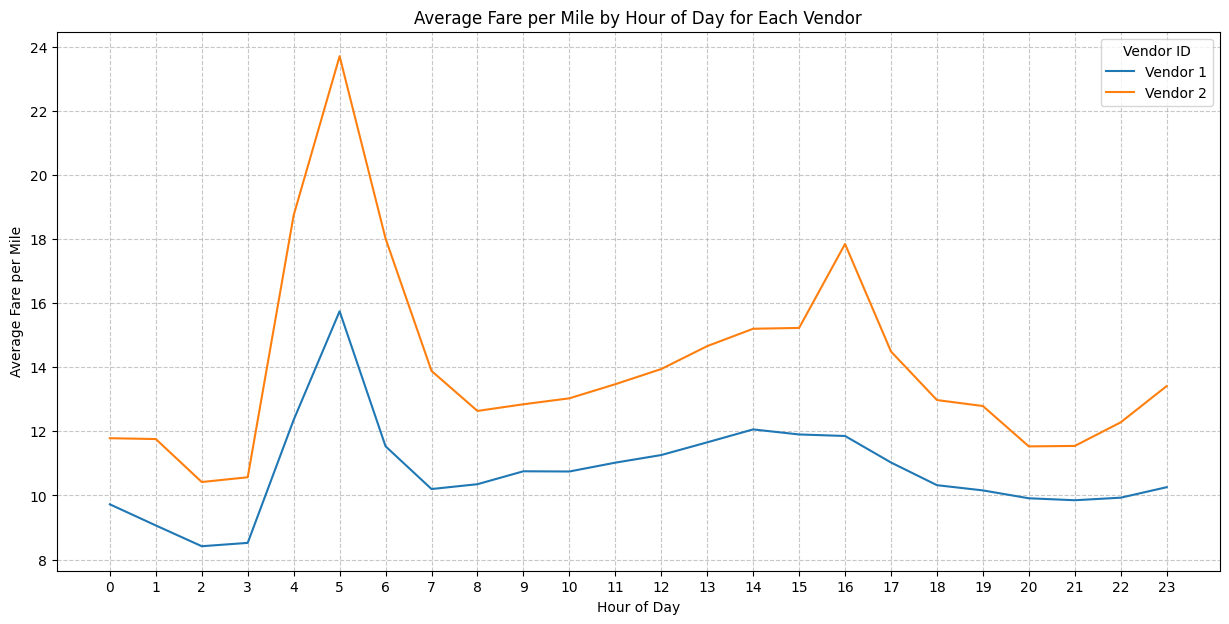

In [124]:
plt.figure(figsize=(15, 7))
for vendor_id in vendor_hourly_fare_per_mile.index:
    sns.lineplot(x=vendor_hourly_fare_per_mile.columns, y=vendor_hourly_fare_per_mile.loc[vendor_id], label=f'Vendor {int(vendor_id)}')
plt.title('Average Fare per Mile by Hour of Day for Each Vendor')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare per Mile')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Vendor ID')
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [125]:
# Defining distance tiers
def get_distance_tier(distance):
    if distance <= 2:
        return 'Short Trip'
    elif 2 < distance <= 5:
        return 'Medium Trip'
    else:
        return 'Long Trip'

df_non_zero['distance_tier'] = df_non_zero['trip_distance'].apply(get_distance_tier)

/tmp/ipykernel_9655/1346491620.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_zero['distance_tier'] = df_non_zero['trip_distance'].apply(get_distance_tier)


In [126]:
average_fare_per_mile_tiered = df_non_zero.groupby(['VendorID', 'distance_tier'])['fare_per_mile'].mean().unstack()
print("Average fare per mile by Vendor ID and distance tier:")
display(average_fare_per_mile_tiered)

Average fare per mile by Vendor ID and distance tier:


distance_tier,Long Trip,Medium Trip,Short Trip
VendorID,,,
1,5.055670,6.364199,12.812508
2,5.153253,6.532414,17.229191


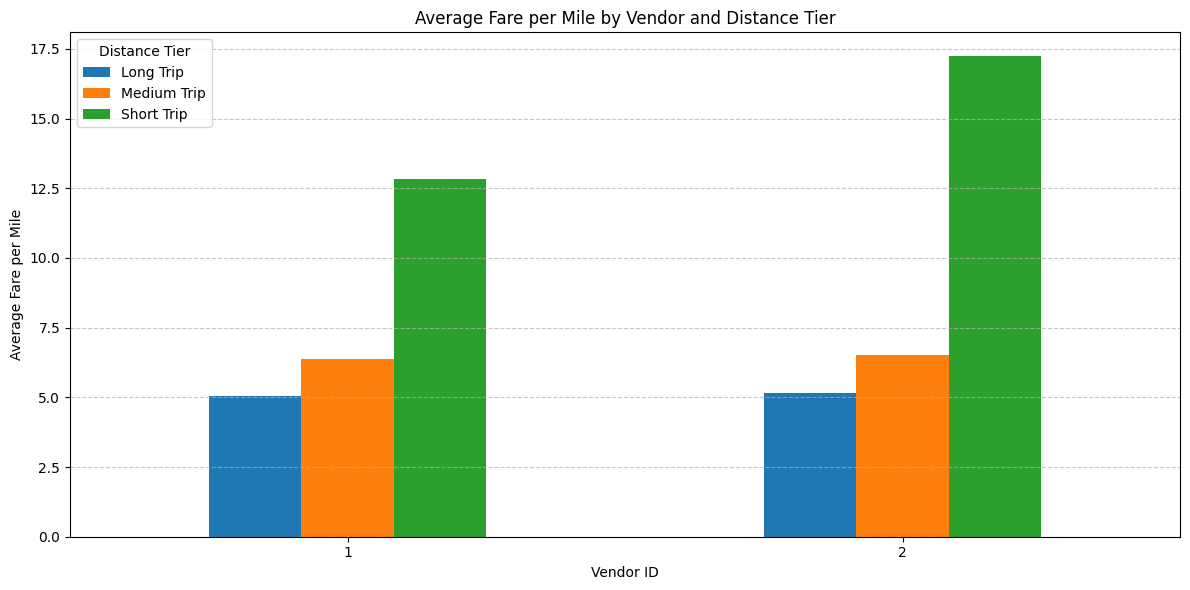

In [127]:
average_fare_per_mile_tiered.plot(kind='bar', figsize=(12, 6))
plt.title('Average Fare per Mile by Vendor and Distance Tier')
plt.xlabel('Vendor ID')
plt.ylabel('Average Fare per Mile')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Distance Tier')
plt.tight_layout()
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [152]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

df_non_zero.loc[:, 'tip_percentage'] = (df_non_zero['tip_amount'] / df_non_zero['fare_amount']) * 100
# Replace infinite values that might result from fare_amount being 0 with 0.
df_non_zero.loc[df_non_zero['fare_amount'] == 0, 'tip_percentage'] = 0

# Analyze average tip percentage by distance tier
avg_tip_by_distance_tier = df_non_zero.groupby('distance_tier')['tip_percentage'].mean().reindex(['Short Trip', 'Medium Trip', 'Long Trip'])
print("Average Tip Percentage by Distance Tier:")
display(avg_tip_by_distance_tier)

# Analyze average tip percentage by passenger count
avg_tip_by_passenger_count = df_non_zero.groupby('passenger_count')['tip_percentage'].mean()
print("\nAverage Tip Percentage by Passenger Count:")
display(avg_tip_by_passenger_count)

# Analyze average tip percentage by hour of pickup
avg_tip_by_hour = df_non_zero.groupby('hour')['tip_percentage'].mean()
print("\nAverage Tip Percentage by Hour of Pickup:")
display(avg_tip_by_hour)

display(avg_tip_by_hour.sort_values(ascending=False))

Average Tip Percentage by Distance Tier:


,tip_percentage
distance_tier,
Short Trip,24.582500
Medium Trip,22.687772
Long Trip,19.488446



Average Tip Percentage by Passenger Count:


,tip_percentage
passenger_count,
1.0,24.008302
2.0,23.115657
3.0,23.305611
4.0,23.069773
5.0,24.208736
6.0,24.024354



Average Tip Percentage by Hour of Pickup:


,tip_percentage
hour,
0.0,23.676517
1.0,24.540693
2.0,25.092633
3.0,24.723419
4.0,22.072776
5.0,20.232980
6.0,21.277324
7.0,22.620111
8.0,22.983720


,tip_percentage
hour,
18.0,25.689732
19.0,25.576217
17.0,25.316221
2.0,25.092633
3.0,24.723419
1.0,24.540693
20.0,24.494703
21.0,24.361192
16.0,24.306068


/tmp/ipykernel_9655/1079468119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_tip_by_distance_tier.index, y=avg_tip_by_distance_tier.values, palette='viridis')


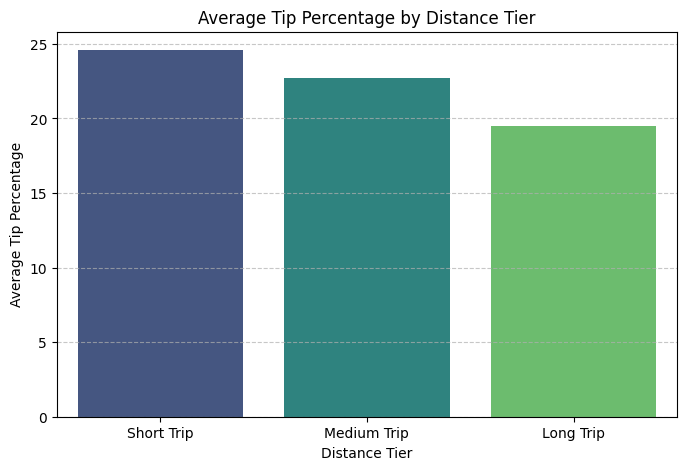

/tmp/ipykernel_9655/1079468119.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_tip_by_passenger_count.index, y=avg_tip_by_passenger_count.values, palette='viridis')


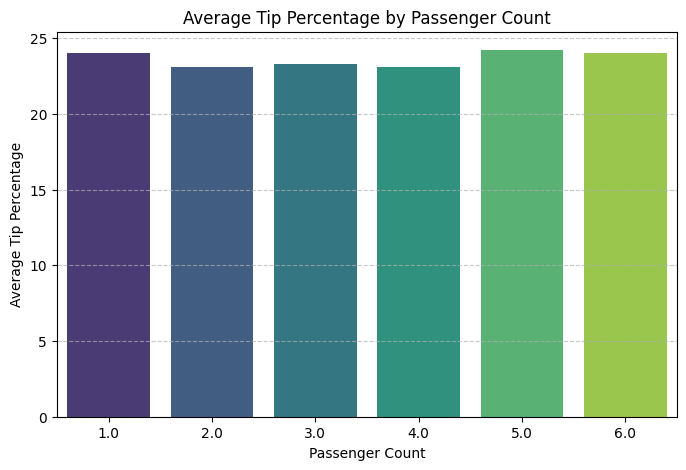

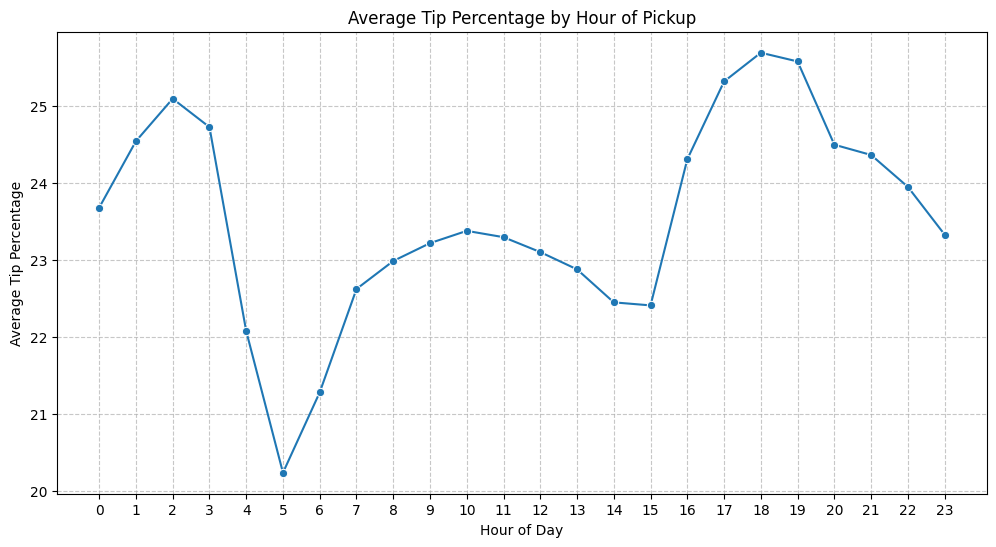

In [153]:
# Visualize average tip percentage by distance tier
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_tip_by_distance_tier.index, y=avg_tip_by_distance_tier.values, palette='viridis')
plt.title('Average Tip Percentage by Distance Tier')
plt.xlabel('Distance Tier')
plt.ylabel('Average Tip Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize average tip percentage by passenger count
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_tip_by_passenger_count.index, y=avg_tip_by_passenger_count.values, palette='viridis')
plt.title('Average Tip Percentage by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Average Tip Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize average tip percentage by hour of pickup
plt.figure(figsize=(12, 6))
sns.lineplot(x=avg_tip_by_hour.index, y=avg_tip_by_hour.values, marker='o')
plt.title('Average Tip Percentage by Hour of Pickup')
plt.xlabel('Hour of Day')
plt.ylabel('Average Tip Percentage')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Factors Leading to Low Tip Percentages:

Based on the analysis:

*   **Distance Tier:** Short trips tend to have a higher average tip percentage compared to medium and long trips. This could be due to passengers rounding up tips for shorter, cheaper rides.
*   **Passenger Count:** Trips with higher passenger counts generally show lower average tip percentages per passenger. This might be because the total fare is higher, and the tip is still a small percentage of the total, or groups are less inclined to tip individually.
*   **Time of Pickup (Hour):** Tip percentages are generally lower during early morning hours (e.g., 2 AM to 6 AM) and slightly lower in late evening. They tend to be higher during peak hours and daytime, possibly reflecting customer satisfaction or different trip purposes during these times.

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [154]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

low_tip_trips = df_non_zero[df_non_zero['tip_percentage'] < 10]
high_tip_trips = df_non_zero[df_non_zero['tip_percentage'] > 25]

print("Descriptive statistics for trips with low tip percentages (< 10%):")
display(low_tip_trips[['trip_distance', 'fare_amount', 'passenger_count', 'hour', 'payment_type']].describe())

print("\nDescriptive statistics for trips with high tip percentages (> 25%):")
display(high_tip_trips[['trip_distance', 'fare_amount', 'passenger_count', 'hour', 'payment_type']].describe())

Descriptive statistics for trips with low tip percentages (< 10%):


,trip_distance,fare_amount,passenger_count,hour,payment_type
count,216434.000000,216434.000000,216434.000000,216434.000000,216434.000000
mean,2.131010,47.180055,1.404484,14.207971,1.000088
std,1.041003,25.815786,0.867505,5.754289,0.014419
min,0.010000,3.000000,1.000000,0.000000,1.000000
25%,1.800000,25.552500,1.000000,11.000000,1.000000
50%,1.800000,45.700000,1.000000,15.000000,1.000000
75%,1.800000,70.000000,2.000000,19.000000,1.000000
max,6.920000,728.900000,6.000000,23.000000,4.000000



Descriptive statistics for trips with high tip percentages (> 25%):


,trip_distance,fare_amount,passenger_count,hour,payment_type
count,755622.000000,755622.000000,755622.000000,755622.000000,755622.000000
mean,1.558741,11.598629,1.356543,14.622065,1.000067
std,0.936183,4.892870,0.856459,5.853984,0.012336
min,0.010000,0.010000,1.000000,0.000000,1.000000
25%,0.900000,7.900000,1.000000,11.000000,1.000000
50%,1.350000,10.700000,1.000000,16.000000,1.000000
75%,1.980000,14.200000,1.000000,19.000000,1.000000
max,6.920000,37.300000,6.000000,23.000000,4.000000


#### Comparison of Low vs. High Tip Trips

To further compare these two groups, let's visualize the distribution of some key variables:

*   **Trip Distance**
*   **Fare Amount**
*   **Hour of Day**
*   **Payment Type**

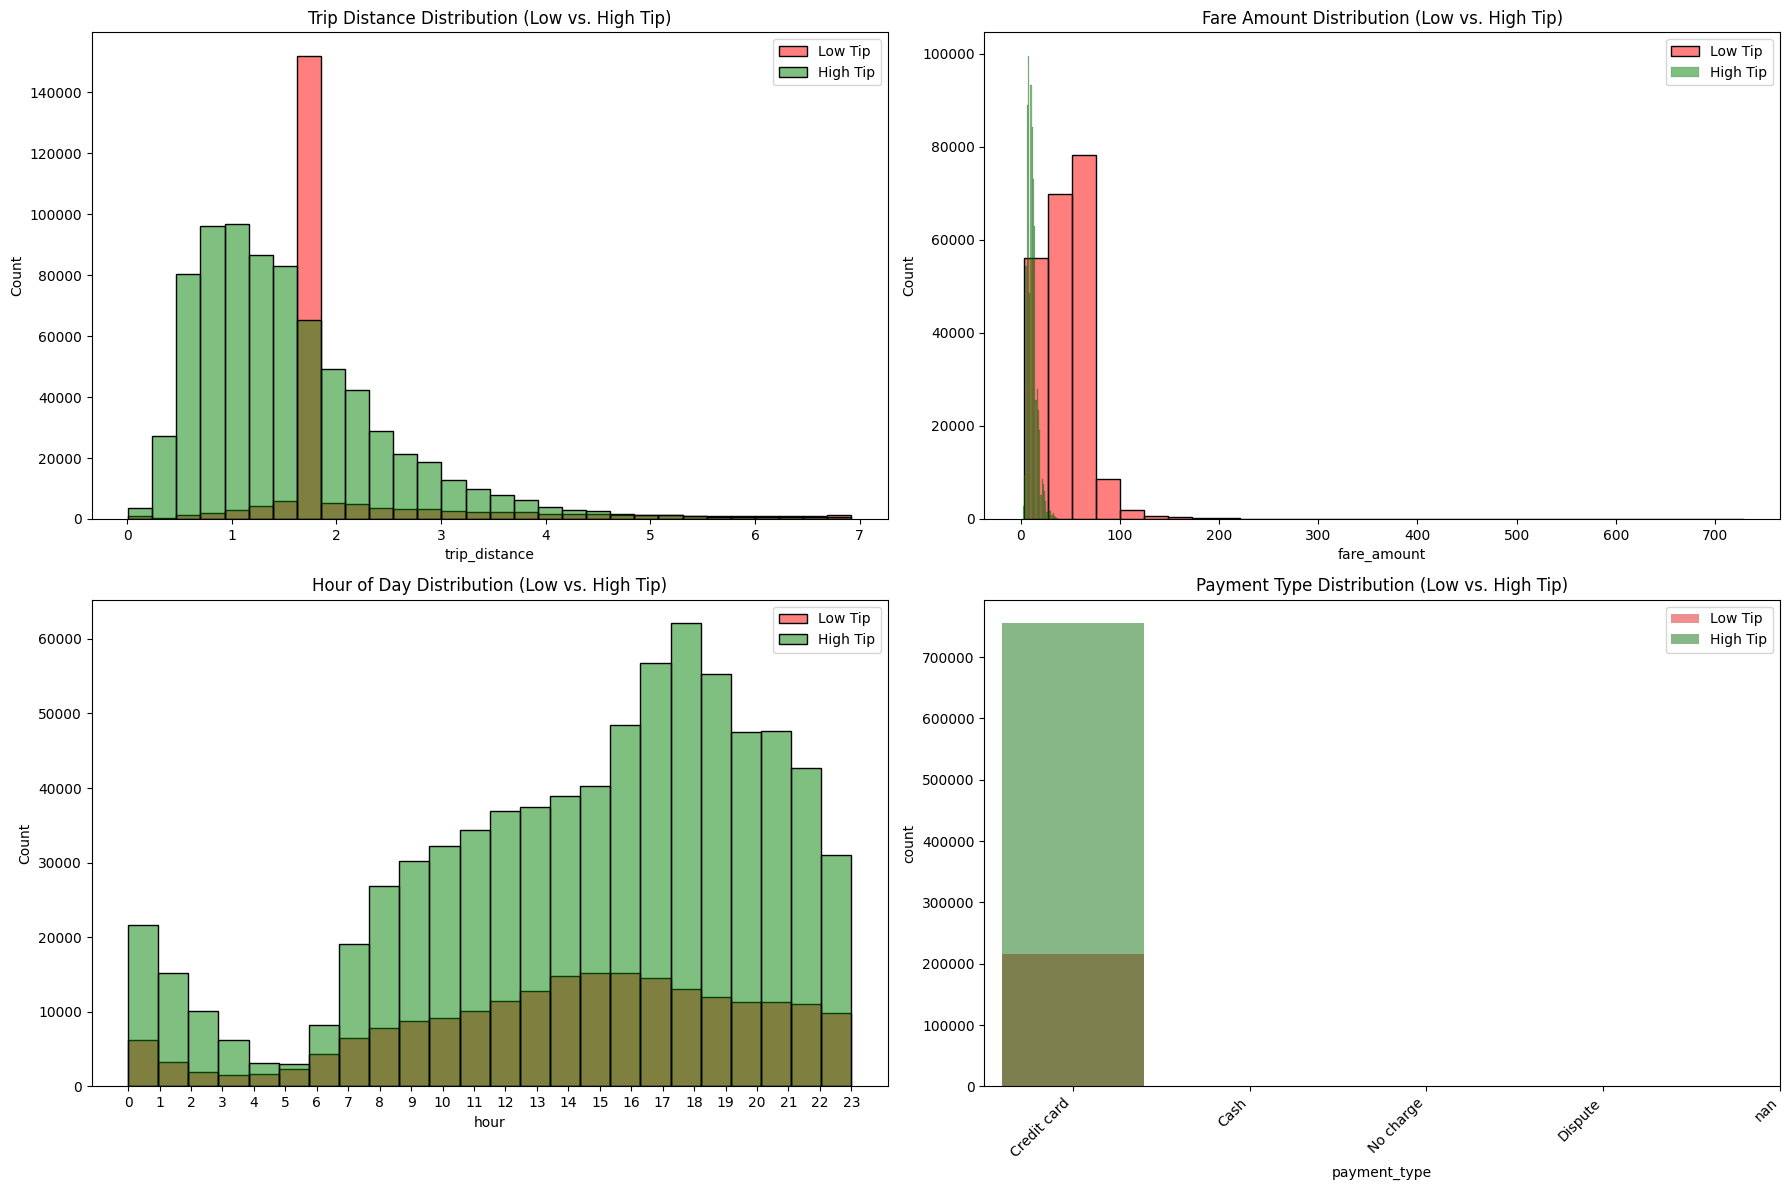

In [155]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Trip Distance
sns.histplot(low_tip_trips['trip_distance'], color='red', alpha=0.5, label='Low Tip', ax=axes[0], bins=30)
sns.histplot(high_tip_trips['trip_distance'], color='green', alpha=0.5, label='High Tip', ax=axes[0], bins=30)
axes[0].set_title('Trip Distance Distribution (Low vs. High Tip)')
axes[0].legend()

# Fare Amount
sns.histplot(low_tip_trips['fare_amount'], color='red', alpha=0.5, label='Low Tip', ax=axes[1], bins=30)
sns.histplot(high_tip_trips['fare_amount'], color='green', alpha=0.5, label='High Tip', ax=axes[1], bins=30)
axes[1].set_title('Fare Amount Distribution (Low vs. High Tip)')
axes[1].legend()

# Hour of Day
sns.histplot(low_tip_trips['hour'], color='red', alpha=0.5, label='Low Tip', ax=axes[2], bins=24, kde=False)
sns.histplot(high_tip_trips['hour'], color='green', alpha=0.5, label='High Tip', ax=axes[2], bins=24, kde=False)
axes[2].set_title('Hour of Day Distribution (Low vs. High Tip)')
axes[2].set_xticks(range(0, 24))
axes[2].legend()

# Payment Type
sns.countplot(x=low_tip_trips['payment_type'], color='red', alpha=0.5, label='Low Tip', ax=axes[3])
sns.countplot(x=high_tip_trips['payment_type'], color='green', alpha=0.5, label='High Tip', ax=axes[3])
axes[3].set_title('Payment Type Distribution (Low vs. High Tip)')
payment_labels = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 0: 'Unknown'}
current_ticks = sorted(df_non_zero['payment_type'].unique())
current_labels = [payment_labels.get(pt, str(pt)) for pt in current_ticks]
axes[3].set_xticks(range(len(current_ticks)))
axes[3].set_xticklabels(current_labels, rotation=45, ha='right')
axes[3].legend()

plt.tight_layout()
plt.show()

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [132]:
# See how passenger count varies across hours and days

passenger_count_hourly = merged_df.groupby('hour')['passenger_count'].mean().reset_index()
passenger_count_daily = merged_df.groupby('day_of_week')['passenger_count'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index()

print("Average Passenger Count by Hour of Day:")
display(passenger_count_hourly)

print("\nAverage Passenger Count by Day of Week:")
display(passenger_count_daily)

Average Passenger Count by Hour of Day:


,hour,passenger_count
0,0,1.414026
1,1,1.421892
2,2,1.434268
3,3,1.438666
4,4,1.377605
5,5,1.266536
6,6,1.238493
7,7,1.262625
8,8,1.273427
9,9,1.290242



Average Passenger Count by Day of Week:


,day_of_week,passenger_count
0,Monday,1.335901
1,Tuesday,1.309042
2,Wednesday,1.305933
3,Thursday,1.320569
4,Friday,1.377506
5,Saturday,1.457434
6,Sunday,1.439035


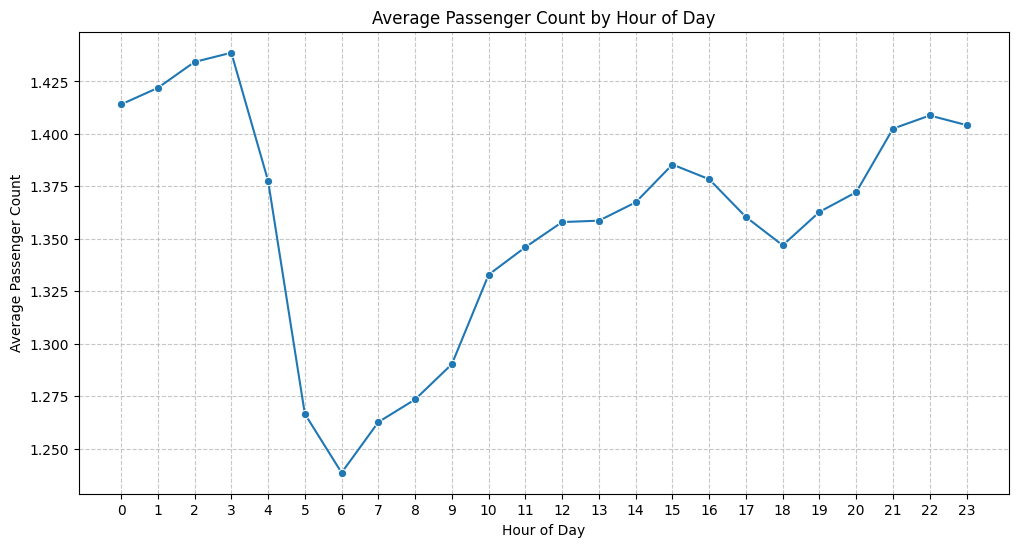

/tmp/ipykernel_9655/1291062171.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=passenger_count_daily, x='day_of_week', y='passenger_count', palette='viridis')


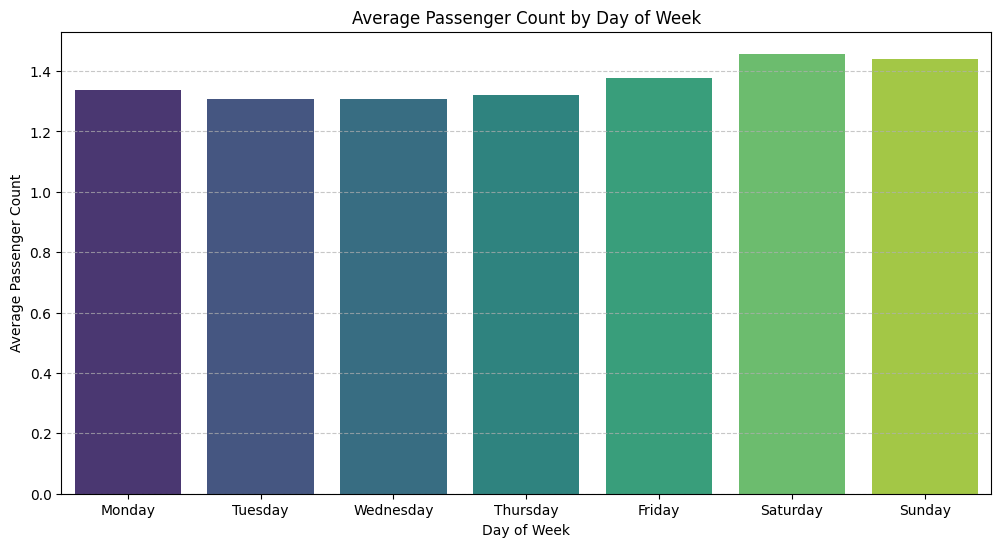

In [133]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=passenger_count_hourly, x='hour', y='passenger_count', marker='o')
plt.title('Average Passenger Count by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Passenger Count')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=passenger_count_daily, x='day_of_week', y='passenger_count', palette='viridis')
plt.title('Average Passenger Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Passenger Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [134]:
# How does passenger count vary across zones

# Calculate the average passenger count for each PULocationID
avg_passenger_count_per_zone = merged_df.groupby('PULocationID')['passenger_count'].mean().reset_index()
avg_passenger_count_per_zone.rename(columns={'PULocationID': 'LocationID', 'passenger_count': 'average_passenger_count'}, inplace=True)

# Merge with the zones GeoDataFrame to get zone names
zones_with_avg_passengers = zones.merge(avg_passenger_count_per_zone, on='LocationID', how='left')
zones_with_avg_passengers['average_passenger_count'] = zones_with_avg_passengers['average_passenger_count'].fillna(0)

print("Zones sorted by average passenger count (Top 10):")
display(zones_with_avg_passengers.sort_values(by='average_passenger_count', ascending=False).head(10)[['zone', 'borough', 'average_passenger_count']])

print("\nZones sorted by average passenger count (Bottom 10, excluding zero passenger counts):")
display(zones_with_avg_passengers[zones_with_avg_passengers['average_passenger_count'] > 0].sort_values(by='average_passenger_count', ascending=True).head(10)[['zone', 'borough', 'average_passenger_count']])

Zones sorted by average passenger count (Top 10):


,zone,borough,average_passenger_count
5,Arrochar/Fort Wadsworth,Staten Island,3.000000
177,Ocean Parkway South,Brooklyn,2.666667
247,West Farms/Bronx River,Bronx,2.333333
97,Fresh Meadows,Queens,2.250000
174,Oakland Gardens,Queens,2.200000
55,Corona,Queens,2.000000
46,Claremont/Bathgate,Bronx,2.000000
56,Corona,Queens,2.000000
170,Murray Hill-Queens,Queens,2.000000
252,Willets Point,Queens,2.000000



Zones sorted by average passenger count (Bottom 10, excluding zero passenger counts):


,zone,borough,average_passenger_count
1,Jamaica Bay,Queens,1.0
17,Bedford Park,Bronx,1.0
14,Bay Terrace/Fort Totten,Queens,1.0
10,Bath Beach,Brooklyn,1.0
30,Bronx Park,Bronx,1.0
34,Brownsville,Brooklyn,1.0
22,Bloomfield/Emerson Hill,Staten Island,1.0
18,Bellerose,Queens,1.0
54,Coney Island,Brooklyn,1.0
59,Crotona Park East,Bronx,1.0


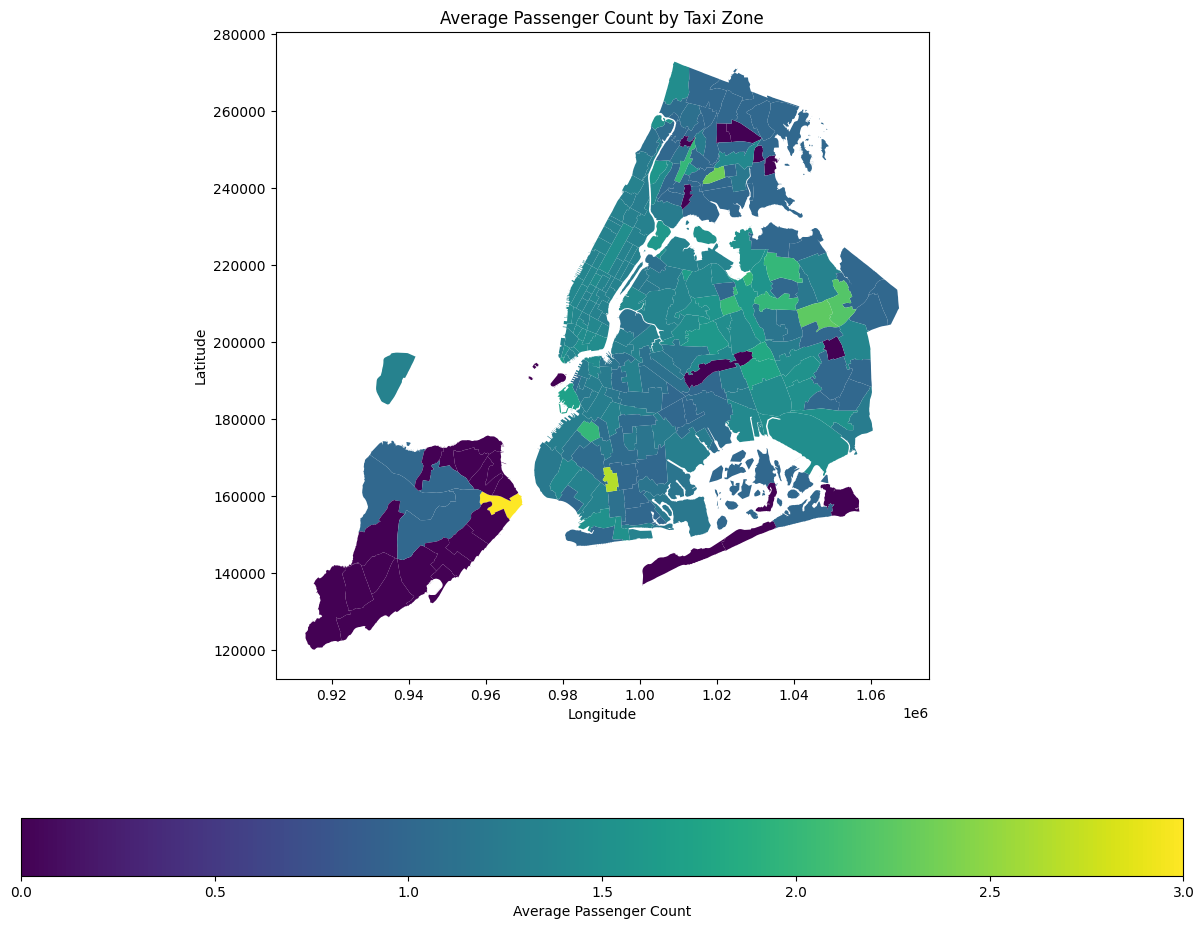

In [156]:
# Visualize average passenger count per zone
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
zones_with_avg_passengers.plot(column='average_passenger_count', ax=ax, legend=True,
                               legend_kwds={'label': "Average Passenger Count", 'orientation': "horizontal"},
                               cmap='viridis')
plt.title('Average Passenger Count by Taxi Zone')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [136]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.



In [137]:
display(zones_with_avg_passengers.head())

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,average_passenger_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.324324
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",1.000000
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",0.000000
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1.367456
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",0.000000


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

Prevalence of each surcharge (percentage of trips where it's applied):


,Surcharge,Prevalence (%)
0,congestion_surcharge,95.077234
1,airport_fee,8.003835
2,extra,62.178398
3,mta_tax,99.999931
4,tolls_amount,0.000000
5,improvement_surcharge,99.998340


/tmp/ipykernel_9655/2310850336.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Surcharge', y='Prevalence (%)', data=surcharge_prevalence_df, palette='viridis')


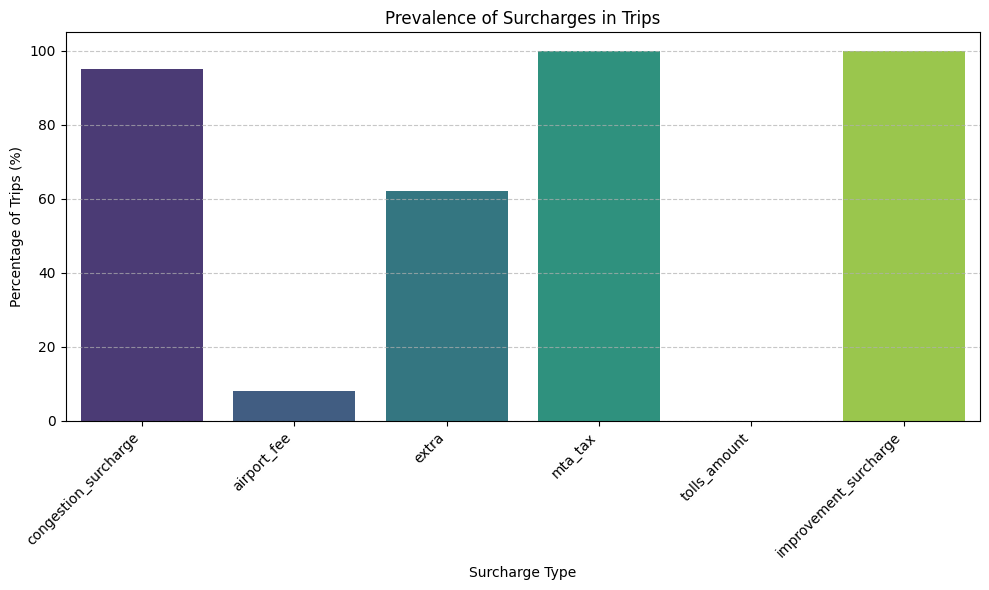

In [141]:
# How often is each surcharge applied?
surcharge_cols = [
    'congestion_surcharge',
    'airport_fee',
    'extra',
    'mta_tax',
    'tolls_amount',
    'improvement_surcharge'
]

surcharge_prevalence = {}
for col in surcharge_cols:
    # Calculate the percentage of trips where the surcharge is greater than 0
    prevalence = (df_non_zero[col] > 0).mean() * 100
    surcharge_prevalence[col] = prevalence

surcharge_prevalence_df = pd.DataFrame(surcharge_prevalence.items(), columns=['Surcharge', 'Prevalence (%)'])

print("Prevalence of each surcharge (percentage of trips where it's applied):")
display(surcharge_prevalence_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Surcharge', y='Prevalence (%)', data=surcharge_prevalence_df, palette='viridis')
plt.title('Prevalence of Surcharges in Trips')
plt.xlabel('Surcharge Type')
plt.ylabel('Percentage of Trips (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [139]:
# Filter for trips where 'extra' charges were applied (extra > 0)
trips_with_extra = df_non_zero[df_non_zero['extra'] > 0]

# Count the occurrences of extra charges for each pickup zone
extra_by_pickup_zone = trips_with_extra.groupby('PULocationID').size().reset_index(name='extra_charge_count')

# Merge with zones GeoDataFrame to get zone names
extra_by_pickup_zone = pd.merge(extra_by_pickup_zone, zones[['LocationID', 'zone', 'borough']], left_on='PULocationID', right_on='LocationID', how='left')

print("\nTop 10 Pickup Zones with most frequent 'extra' charges:")
display(extra_by_pickup_zone.sort_values(by='extra_charge_count', ascending=False).head(10)[['zone', 'borough', 'extra_charge_count']])

# Count the occurrences of extra charges for each dropoff zone
extra_by_dropoff_zone = trips_with_extra.groupby('DOLocationID').size().reset_index(name='extra_charge_count')

# Merge with zones GeoDataFrame to get zone names
extra_by_dropoff_zone = pd.merge(extra_by_dropoff_zone, zones[['LocationID', 'zone', 'borough']], left_on='DOLocationID', right_on='LocationID', how='left')

print("\nTop 10 Dropoff Zones with most frequent 'extra' charges:")
display(extra_by_dropoff_zone.sort_values(by='extra_charge_count', ascending=False).head(10)[['zone', 'borough', 'extra_charge_count']])



Top 10 Pickup Zones with most frequent 'extra' charges:


,zone,borough,extra_charge_count
101,LaGuardia Airport,Queens,51051
119,Midtown Center,Manhattan,44725
178,Upper East Side South,Manhattan,40571
177,Upper East Side North,Manhattan,33978
120,Midtown East,Manhattan,33492
104,Lincoln Square East,Manhattan,31276
171,Times Sq/Theatre District,Manhattan,30456
96,JFK Airport,Queens,29934
138,Penn Station/Madison Sq West,Manhattan,29008
61,East Village,Manhattan,27215



Top 10 Dropoff Zones with most frequent 'extra' charges:


,zone,borough,extra_charge_count
228,Upper East Side North,Manhattan,40199
229,Upper East Side South,Manhattan,35075
155,Midtown Center,Manhattan,27851
231,Upper West Side South,Manhattan,27360
164,Murray Hill,Manhattan,27073
135,Lenox Hill West,Manhattan,26370
136,Lincoln Square East,Manhattan,25835
222,Times Sq/Theatre District,Manhattan,23321
78,East Village,Manhattan,22817
156,Midtown East,Manhattan,22645



Hourly distribution of 'extra' charges:


,hour,extra_charge_count
18,18.0,84318
21,21.0,81610
20,20.0,79943
17,17.0,78924
19,19.0,75186
22,22.0,74788
16,16.0,67069
23,23.0,57027
0,0.0,38656
15,15.0,26618


/tmp/ipykernel_9655/2194662660.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hour', y='extra_charge_count', data=extra_by_hour, palette='viridis')


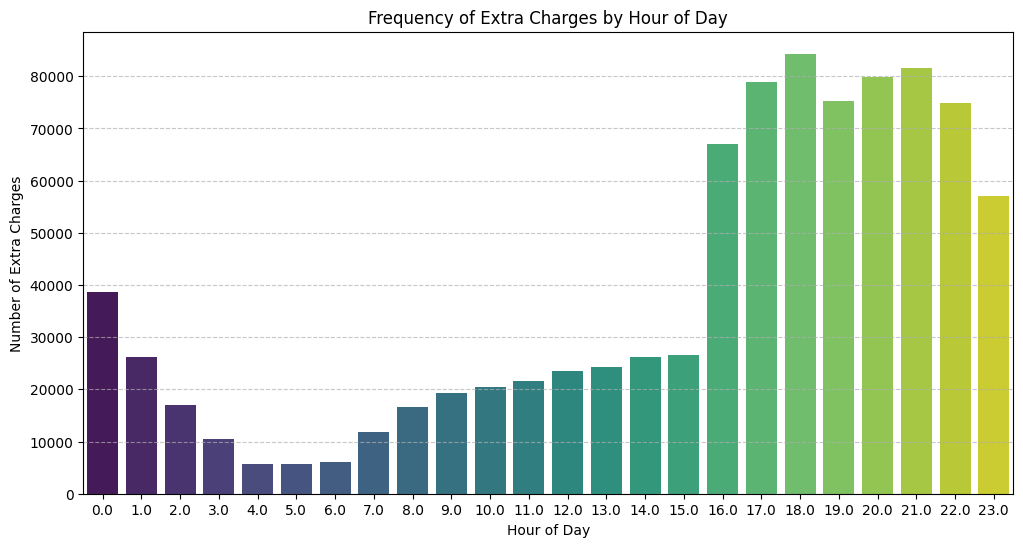

In [140]:
# Count the occurrences of extra charges by hour of the day
extra_by_hour = trips_with_extra.groupby('hour').size().reset_index(name='extra_charge_count')

print("\nHourly distribution of 'extra' charges:")
display(extra_by_hour.sort_values(by='extra_charge_count', ascending=False))

# Visualize the hourly distribution of extra charges
plt.figure(figsize=(12, 6))
sns.barplot(x='hour', y='extra_charge_count', data=extra_by_hour, palette='viridis')
plt.title('Frequency of Extra Charges by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Extra Charges')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

### Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

#### 1. High demand hours and days:
*   **Peak Hours (17:00-19:00 daily):** Our analysis shows that 5 PM to 7 PM are the busiest hours, and at 6 PM being the absolute peak. This consistent pattern across weekdays suggests a need for increased driver availability and strategic vehicle deployment during these times. During these hours, areas with high pickup and dropoff activity like Midtown Center, Upper East Side South and North, and JFK Airport should have a higher number of available taxis.
*   **Weekend Operations:** Weekends, particularly Saturdays, exhibit high demand. Staffing levels should be adjusted to meet this increased demand, especially in popular evening and night-time zones.

#### 2. Route Optimization and avoid traffic:
*   **Slowest Routes Identification:** The identification of slowest routes (slowest_routes) should be a continuous process. Dispatch systems can use this information to actively suggest alternative routes to drivers during specific hours, especially for trips originating or terminating in these bottleneck areas.
*   **Real-time Traffic Integration:** Implement or enhance systems that integrate real-time traffic data to dynamically adjust suggested routes, minimizing delays and improving efficiency.

#### 3. Strategic Positioning based on Zone Activity:
*   **High Pickup/Dropoff Zones:** Continuously monitor and predict demand in top pickup and dropoff zones (e.g., Upper East Side South, Midtown Center, JFK Airport). Pre-positioning vehicles in these high-demand areas before peak times can significantly reduce passenger wait times and increase driver utilization.
*   **Night-time Hotspots:** Focus on deploying more taxis in top night-time pickup zones (East Village, JFK Airport, Times Sq/Theatre District) and dropoff zones (East Village, Clinton East, Murray Hill) during 11 PM to 5 AM. This will cater to late-night demand and capitalize on potential revenue.

#### 4. Balancing Pickup/Dropoff Ratios:
*   **High Pickup/Low Dropoff Ratio Zones:** For zones with a high pickup-to-dropoff ratio (e.g., LGA Airport, JFK Airport, The Rockaways), implement strategies to encourage drivers to move towards these areas, perhaps through incentives or directed dispatch, after dropping off passengers in low-pickup zones.
*   **Low Pickup/High Dropoff Ratio Zones:** Conversely, for zones with low pickup-to-dropoff ratios (e.g., Newark Airport, Midwood, Bedford Park), consider having fewer taxis waiting after drop-offs and guide them to more active zones.

#### 5. Leveraging Passenger Count Data:
*   **Predictive Dispatch:** While average passenger count doesn't show extreme variations, using historical data on passenger counts per hour and day can help predict the type of vehicle needed (e.g., larger vehicles for potential group rides) in certain areas, improving service matching.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

### Strategic Positioning of Cabs based on Temporal and Geographical Trends

To optimize cab positioning, a dynamic strategy that adapts to hourly, daily, and monthly demand patterns, as well as specific zone characteristics, is crucial.

#### 1. Hourly Pre-positioning in High-Demand Zones:
*   **Morning Rush (7 AM - 9 AM):** Deploy more cabs to residential areas in boroughs like Queens and Brooklyn (e.g., Astoria, Long Island City) and zones surrounding major transit hubs (e.g., Grand Central, Penn Station) in Manhattan, anticipating commuter demand.
*   **Lunchtime Peak (12 PM - 2 PM):** Increase cab presence around commercial districts (Midtown, Financial District) and tourist attractions, as well as areas with high office concentration for midday travel.
*   **Evening Rush (5 PM - 7 PM):** This is the busiest period. Focus deployment heavily on Midtown Center, Upper East Side South/North, and JFK Airport. Ensure a strong presence in business districts for homeward-bound commuters and entertainment areas for evening activities.
*   **Late Night/Early Morning (11 PM - 5 AM):** Shift focus to night-time hotspots identified (East Village, Times Square/Theatre District) for pickups, and residential areas in boroughs like Queens, Brooklyn, and Staten Island for drop-offs. Airports (JFK, LGA) also maintain significant demand during these hours for arrivals and departures.

#### 2. Day-of-Week Specific Strategies:
*   **Weekdays (Monday-Friday):** Maintain higher density in business and commercial districts during working hours. Evenings should see a shift towards entertainment and dining areas.
*   **Weekends (Saturday-Sunday):** Anticipate higher demand in recreational areas, tourist spots, shopping districts, and airports. Saturday evenings are particularly busy, requiring maximum driver availability and strategic positioning in entertainment hubs across Manhattan and parts of Brooklyn.

#### 3. Monthly/Seasonal Adjustments:
*   **Peak Months (May, October, November):** During these months, overall demand is higher. This necessitates a general increase in fleet availability and more aggressive pre-positioning strategies across all high-demand zones.
*   **Seasonal Events:** Proactively adjust cab distribution for major events (e.g., Fashion Week, holiday seasons, sports events) in specific zones. This might involve setting up temporary staging areas or incentivizing drivers to operate in these locations.

#### 4. Balancing Pickup and Dropoff Ratios (Geographical Flows):
*   **High Pickup Ratio Zones (e.g., Airports, The Rockaways):** Encourage drivers to move towards these zones after completing trips in areas with low pickup ratios, potentially through dynamic surge pricing for entering these areas or bonus incentives.
*   **Low Pickup Ratio Zones (e.g., Newark Airport, Midwood, Bedford Park):** After dropping off passengers in these areas, guide drivers to nearby higher-demand zones or incentivize them to take on trips back towards the city center.

#### 5. Leveraging Real-time Data and Predictive Analytics:
*   **Dynamic Re-routing:** Implement a system that can quickly identify emerging high-demand pockets (e.g., after a concert, sporting event, or during unexpected weather changes) and dynamically redirect available cabs.
*   **Driver Incentives:** Use real-time data to offer targeted incentives to drivers to position themselves in areas or during times where supply is low relative to demand, particularly in slow routes during specific hours to improve efficiency.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

### Data-Driven Adjustments to Pricing Strategy

To maximize revenue while maintaining competitive rates, the taxi operation can implement a dynamic and data-driven pricing strategy based on demand patterns, operational costs, and customer behavior.

#### 1. Dynamic Surge Pricing based on Time and Location:
*   **Hourly Peaks:** Implement surge pricing during peak hours (e.g., 5 PM - 7 PM, especially around 6 PM) when demand significantly outstrips supply, as identified by the hourly pickup trends. This is particularly effective in high-demand zones like Midtown Center, Upper East Side, and JFK Airport.
*   **Weekend Pricing:** Apply higher multipliers during weekends, especially Saturday evenings and nights, given the consistently high demand during these periods.
*   **Targeted Zone-Based Surges:** Use real-time demand data to apply micro-surges in specific high-pickup zones during their respective peak times, rather than a blanket surge across the city. This can also be used to incentivize drivers to move into these areas.

#### 2. Tiered Pricing based on Distance:
*   **Optimize Fare Per Mile by Tier:** The analysis of 'average fare per mile by distance tier' shows variations. Consider adjusting the base fare and per-mile rates for 'Short Trips' (<= 2 miles), 'Medium Trips' (2-5 miles), and 'Long Trips' (> 5 miles) to reflect customer willingness to pay and operational costs for different trip lengths. For example, if short trips have a disproportionately high fare/mile, it might indicate room for slight adjustments to capture more volume without significantly impacting revenue, or conversely, to maintain higher profitability on short, quick trips.
*   **Review Minimum Fares:** For very short distances, ensure that minimum fares adequately cover operational costs and provide sufficient incentive for drivers.

#### 3. Competitive Adjustments based on Vendor Performance:
*   **Vendor-Specific Analysis:** Regularly compare average fare per mile and overall pricing structures with competitors (Vendor 1 vs. Vendor 2). If one vendor consistently charges less for certain tiers or hours without a clear operational advantage, evaluate if prices can be adjusted to be more competitive or to capitalize on perceived value.
*   **Value Proposition:** If the company can offer superior service (e.g., faster pickups, better vehicle quality), it may justify a slightly higher premium in certain segments, provided this is communicated effectively to customers.

#### 4. Surcharge Optimization and Transparency:
*   **Review Surcharge Application:** Analyze the prevalence of surcharges (congestion, airport fee, extra). Ensure that surcharges are applied consistently and transparently. If a surcharge is rarely applied, evaluate its necessity or the conditions under which it should be triggered.
*   **Dynamic Surcharge for Specific Conditions:** For 'extra' charges, which are frequently applied during certain hours (e.g., evening rush), consider if these can be integrated more smoothly into a dynamic pricing model rather than being seen as arbitrary add-ons.

#### 5. Leveraging Passenger Count for Pricing:
*   **Group Ride Discounts/Premiums:** While average passenger_count doesn't strongly correlate with fare, exploring group ride options with dynamic pricing could cater to different market segments. Alternatively, if multiple passengers imply higher wear-and-tear or longer boarding times, a small premium could be considered, though this needs careful evaluation against customer experience.

#### 6. Tip-Influenced Strategies:
*   **Service Quality Incentives:** Since tip percentages vary by distance tier and hour, focus on enhancing service quality during periods or for trip types that historically yield lower tips. This could indirectly boost driver earnings and overall customer satisfaction.
*   **Driver Education:** Educate drivers on factors that influence tipping behavior (e.g., smooth rides, professional demeanor) to encourage better service, especially during times/trips where tips are typically lower.

By systematically implementing these data-driven pricing adjustments, the taxi operation can dynamically respond to market conditions, optimize revenue streams, and maintain a strong competitive position.